# PSY 39200 Introduction to Computational Psychology and AI

## Week 01 Model Types

## There are 4 sets of questions and 0 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### Part of this tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed): https://neuromatch.io/open-education-resources/

# Introduction  

**Models** are used to help us understand the world.



Because modeling is the essencial part of computational cognitive neuroscience, it is important to discuss what are different kinds of models and their advantages and disadvantages.



There are many different ways to classify models into different categories. One way of classifying models is classifying them into **what models**, **how models**, and **why models** (Dayan and Abbott, 2001):   

(1) What models


(2) How models


(3) Why models




Another way of classifying models is based on **David Marr's three levels of analysis**:

(1) Computational Level



(2) Algorithmic (or Representational) Level



(3) Implementational (or Hardware) Level




Models can also be classified into two categories: **theory-driven models** and **data-driven models**.

(1) Theory-driven models


(2) Data-driven models





In addition, sometimes it is also possible to classify models into **computational models** and **mathematical models**.

(1) Mathematical models

(2) Computational models






# Set Up Code

In [1]:
# @title Set Up Code

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import patches, transforms, gridspec
from scipy.optimize import fsolve
from collections import namedtuple

# Figure Settings

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
from ipywidgets import GridspecLayout, HBox, VBox, FloatSlider, Layout, ToggleButtons
from ipywidgets import interactive, interactive_output, Checkbox, Select
from IPython.display import clear_output
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

import warnings
warnings.filterwarnings("ignore")


# Plotting functions

def plot_isis(single_neuron_isis):
  plt.hist(single_neuron_isis, bins=50, histtype="stepfilled")
  plt.axvline(single_neuron_isis.mean(), color="orange", label="Mean ISI")
  plt.xlabel("ISI duration (s)")
  plt.ylabel("Number of spikes")
  plt.legend()



def histogram(counts, bins, vlines=(), ax=None, ax_args=None, **kwargs):
  """Plot a step histogram given counts over bins."""
  if ax is None:
    _, ax = plt.subplots()

  # duplicate the first element of `counts` to match bin edges
  counts = np.insert(counts, 0, counts[0])

  ax.fill_between(bins, counts, step="pre", alpha=0.4, **kwargs)  # area shading
  ax.plot(bins, counts, drawstyle="steps", **kwargs)  # lines

  for x in vlines:
    ax.axvline(x, color='r', linestyle='dotted')  # vertical line

  if ax_args is None:
    ax_args = {}

  # heuristically set max y to leave a bit of room
  ymin, ymax = ax_args.get('ylim', [None, None])
  if ymax is None:
    ymax = np.max(counts)
    if ax_args.get('yscale', 'linear') == 'log':
      ymax *= 1.5
    else:
      ymax *= 1.1
      if ymin is None:
        ymin = 0

  if ymax == ymin:
    ymax = None

  ax_args['ylim'] = [ymin, ymax]

  ax.set(**ax_args)
  ax.autoscale(enable=False, axis='x', tight=True)

def plot_neuron_stats(v, spike_times):
  fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

  # membrane voltage trace
  ax1.plot(v[0:100])
  ax1.set(xlabel='Time', ylabel='Voltage')
  # plot spike events
  for x in spike_times:
    if x >= 100:
      break
    ax1.axvline(x, color='red')

  # ISI distribution
  if len(spike_times)>1:
    isi = np.diff(spike_times)
    n_bins = np.arange(isi.min(), isi.max() + 2) - .5
    counts, bins = np.histogram(isi, n_bins)
    vlines = []
    if len(isi) > 0:
      vlines = [np.mean(isi)]
    xmax = max(20, int(bins[-1])+5)
    histogram(counts, bins, vlines=vlines, ax=ax2, ax_args={
      'xlabel': 'Inter-spike interval',
      'ylabel': 'Number of intervals',
      'xlim': [0, xmax]
    })
  else:
    ax2.set(xlabel='Inter-spike interval',
           ylabel='Number of intervals')
  plt.show()


def plot_pmf(pmf,isi_range):
  """Plot the probability mass function."""
  ymax = max(0.2, 1.05 * np.max(pmf))
  pmf_ = np.insert(pmf, 0, pmf[0])
  plt.plot(bins, pmf_, drawstyle="steps")
  plt.fill_between(bins, pmf_, step="pre", alpha=0.4)
  plt.title(f"Neuron {neuron_idx}")
  plt.xlabel("Inter-spike interval (s)")
  plt.ylabel("Probability mass")
  plt.xlim(isi_range)
  plt.ylim([0, ymax])


from matplotlib import colors

def plot_joint_probs(P, ):
  assert np.all(P >= 0), "probabilities should be >= 0"
  # normalize if not
  P = P / np.sum(P)
  marginal_y = np.sum(P,axis=1)
  marginal_x = np.sum(P,axis=0)

  # definitions for the axes
  left, width = 0.1, 0.65
  bottom, height = 0.1, 0.65
  spacing = 0.005

  # start with a square Figure
  fig = plt.figure(figsize=(5, 5))

  joint_prob = [left, bottom, width, height]
  rect_histx = [left, bottom + height + spacing, width, 0.2]
  rect_histy = [left + width + spacing, bottom, 0.2, height]

  rect_x_cmap = plt.cm.Blues
  rect_y_cmap = plt.cm.Reds

  # Show joint probs and marginals
  ax = fig.add_axes(joint_prob)
  ax_x = fig.add_axes(rect_histx, sharex=ax)
  ax_y = fig.add_axes(rect_histy, sharey=ax)

  # Show joint probs and marginals
  ax.matshow(P,vmin=0., vmax=1., cmap='Greys')
  ax_x.bar(0, marginal_x[0], facecolor=rect_x_cmap(marginal_x[0]))
  ax_x.bar(1, marginal_x[1], facecolor=rect_x_cmap(marginal_x[1]))
  ax_y.barh(0, marginal_y[0], facecolor=rect_y_cmap(marginal_y[0]))
  ax_y.barh(1, marginal_y[1], facecolor=rect_y_cmap(marginal_y[1]))
  # set limits
  ax_x.set_ylim([0, 1])
  ax_y.set_xlim([0, 1])

  # show values
  ind = np.arange(2)
  x,y = np.meshgrid(ind,ind)
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{P[i, j]:.2f}"
    ax.text(j,i, c, va='center', ha='center', color='black')
  for i in ind:
    v = marginal_x[i]
    c = f"{v:.2f}"
    ax_x.text(i, v +0.1, c, va='center', ha='center', color='black')
    v = marginal_y[i]
    c = f"{v:.2f}"
    ax_y.text(v+0.2, i, c, va='center', ha='center', color='black')

  # set up labels
  ax.xaxis.tick_bottom()
  ax.yaxis.tick_left()
  ax.set_xticks([0,1])
  ax.set_yticks([0,1])
  ax.set_xticklabels(['Silver', 'Gold'])
  ax.set_yticklabels(['Small', 'Large'])
  ax.set_xlabel('color')
  ax.set_ylabel('size')
  ax_x.axis('off')
  ax_y.axis('off')
  return fig


def plot_prior_likelihood_posterior(prior, likelihood, posterior):
  # definitions for the axes
  left, width = 0.05, 0.3
  bottom, height = 0.05, 0.9
  padding = 0.12
  small_width = 0.1
  left_space = left + small_width + padding
  added_space = padding + width

  fig = plt.figure(figsize=(12, 4))

  rect_prior = [left, bottom, small_width, height]
  rect_likelihood = [left_space , bottom , width, height]
  rect_posterior = [left_space +  added_space, bottom , width, height]

  ax_prior = fig.add_axes(rect_prior)
  ax_likelihood = fig.add_axes(rect_likelihood, sharey=ax_prior)
  ax_posterior = fig.add_axes(rect_posterior, sharey = ax_prior)

  rect_colormap = plt.cm.Blues

  # Show posterior probs and marginals
  ax_prior.barh(0, prior[0], facecolor=rect_colormap(prior[0, 0]))
  ax_prior.barh(1, prior[1], facecolor=rect_colormap(prior[1, 0]))
  ax_likelihood.matshow(likelihood, vmin=0., vmax=1., cmap='Reds')
  ax_posterior.matshow(posterior, vmin=0., vmax=1., cmap='Greens')

  # Probabilities plot details
  ax_prior.set(xlim=[1, 0], xticks=[], yticks=[0, 1],
                yticklabels=['left', 'right'], title="Prior p(s)")
  ax_prior.yaxis.tick_right()
  ax_prior.spines['left'].set_visible(False)
  ax_prior.spines['bottom'].set_visible(False)

  # Likelihood plot details
  ax_likelihood.set(xticks=[0, 1], xticklabels=['fish', 'no fish'],
                    yticks=[0, 1], yticklabels=['left', 'right'],
                    ylabel='state (s)', xlabel='measurement (m)',
                    title='Likelihood p(m (left) | s)')
  ax_likelihood.xaxis.set_ticks_position('bottom')
  ax_likelihood.spines['left'].set_visible(False)
  ax_likelihood.spines['bottom'].set_visible(False)

  # Posterior plot details
  ax_posterior.set(xticks=[0, 1], xticklabels=['fish', 'no fish'],
                    yticks=[0, 1], yticklabels=['left', 'right'],
                    ylabel='state (s)', xlabel='measurement (m)',
                    title='Posterior p(s | m)')
  ax_posterior.xaxis.set_ticks_position('bottom')
  ax_posterior.spines['left'].set_visible(False)
  ax_posterior.spines['bottom'].set_visible(False)

  # show values
  ind = np.arange(2)
  x,y = np.meshgrid(ind,ind)
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{posterior[i, j]:.2f}"
    ax_posterior.text(j, i, c, va='center', ha='center', color='black')
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{likelihood[i, j]:.2f}"
    ax_likelihood.text(j, i, c, va='center', ha='center', color='black')
  for i in ind:
    v = prior[i, 0]
    c = f"{v:.2f}"
    ax_prior.text(v+0.2, i, c, va='center', ha='center', color='black')


def plot_prior_likelihood(ps, p_a_s1, p_a_s0, measurement):
  likelihood = np.asarray([[p_a_s1, 1-p_a_s1], [p_a_s0, 1-p_a_s0]])
  assert 0.0 <= ps <= 1.0
  prior = np.asarray([ps, 1 - ps])
  if measurement == "Fish":
    posterior = likelihood[:, 0] * prior
  else:
    posterior = (likelihood[:, 1] * prior).reshape(-1)
  posterior /= np.sum(posterior)

  # definitions for the axes
  left, width = 0.05, 0.3
  bottom, height = 0.05, 0.9
  padding = 0.12
  small_width = 0.2
  left_space = left + small_width + padding
  small_padding = 0.05

  fig = plt.figure(figsize=(12, 4))

  rect_prior = [left, bottom, small_width, height]
  rect_likelihood = [left_space , bottom , width, height]
  rect_posterior = [left_space + width + small_padding, bottom , small_width, height]

  ax_prior = fig.add_axes(rect_prior)
  ax_likelihood = fig.add_axes(rect_likelihood, sharey=ax_prior)
  ax_posterior = fig.add_axes(rect_posterior, sharey=ax_prior)

  prior_colormap = plt.cm.Blues
  posterior_colormap = plt.cm.Greens

  # Show posterior probs and marginals
  ax_prior.barh(0, prior[0], facecolor=prior_colormap(prior[0]))
  ax_prior.barh(1, prior[1], facecolor=prior_colormap(prior[1]))
  ax_likelihood.matshow(likelihood, vmin=0., vmax=1., cmap='Reds')
  ax_posterior.barh(0, posterior[0], facecolor=posterior_colormap(posterior[0]))
  ax_posterior.barh(1, posterior[1], facecolor=posterior_colormap(posterior[1]))

  # Probabilities plot details
  ax_prior.set(xlim=[1, 0], yticks=[0, 1], yticklabels=['left', 'right'],
                title="Prior p(s)", xticks=[])
  ax_prior.yaxis.tick_right()
  ax_prior.spines['left'].set_visible(False)
  ax_prior.spines['bottom'].set_visible(False)

  # Likelihood plot details
  ax_likelihood.set(xticks=[0, 1], xticklabels=['fish', 'no fish'],
                    yticks=[0, 1], yticklabels=['left', 'right'],
                    ylabel='state (s)', xlabel='measurement (m)',
                    title='Likelihood p(m | s)')
  ax_likelihood.xaxis.set_ticks_position('bottom')
  ax_likelihood.spines['left'].set_visible(False)
  ax_likelihood.spines['bottom'].set_visible(False)

  # Posterior plot details
  ax_posterior.set(xlim=[0, 1], xticks=[], yticks=[0, 1],
                    yticklabels=['left', 'right'],
                    title="Posterior p(s | m)")
  ax_posterior.spines['left'].set_visible(False)
  ax_posterior.spines['bottom'].set_visible(False)

  # show values
  ind = np.arange(2)
  x,y = np.meshgrid(ind, ind)
  for i in ind:
    v = posterior[i]
    c = f"{v:.2f}"
    ax_posterior.text(v+0.2, i, c, va='center', ha='center', color='black')
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{likelihood[i, j]:.2f}"
    ax_likelihood.text(j, i, c, va='center', ha='center', color='black')
  for i in ind:
    v = prior[i]
    c = f"{v:.2f}"
    ax_prior.text(v+0.2, i, c, va='center', ha='center', color='black')
  plt.show()
  return fig


def plot_utility(ps):
  prior = np.asarray([ps, 1 - ps])

  utility = np.array([[2, -3], [-2, 1]])

  expected = prior @ utility

  # definitions for the axes
  left, width = 0.05, 0.16
  bottom, height = 0.05, 0.9
  padding = 0.02
  small_width = 0.1
  left_space = left + small_width + padding
  added_space = padding + width

  fig = plt.figure(figsize=(17, 3))

  rect_prior = [left, bottom, small_width, height]
  rect_utility = [left + added_space , bottom , width, height]
  rect_expected = [left + 2* added_space, bottom , width, height]

  ax_prior = fig.add_axes(rect_prior)
  ax_utility = fig.add_axes(rect_utility, sharey=ax_prior)
  ax_expected = fig.add_axes(rect_expected)

  rect_colormap = plt.cm.Blues

  # Data of plots
  ax_prior.barh(0, prior[0], facecolor=rect_colormap(prior[0]))
  ax_prior.barh(1, prior[1], facecolor=rect_colormap(prior[1]))
  ax_utility.matshow(utility, cmap='cool')
  norm = colors.Normalize(vmin=-3, vmax=3)
  ax_expected.bar(0, expected[0], facecolor=rect_colormap(norm(expected[0])))
  ax_expected.bar(1, expected[1], facecolor=rect_colormap(norm(expected[1])))

  # Probabilities plot details
  ax_prior.set(xlim=[1, 0], xticks=[], yticks=[0, 1],
                yticklabels=['left', 'right'], title="Probability of state")
  ax_prior.yaxis.tick_right()
  ax_prior.spines['left'].set_visible(False)
  ax_prior.spines['bottom'].set_visible(False)

  # Utility plot details
  ax_utility.set(xticks=[0, 1], xticklabels=['left', 'right'],
                  yticks=[0, 1], yticklabels=['left', 'right'],
                  ylabel='state (s)', xlabel='action (a)',
                  title='Utility')
  ax_utility.xaxis.set_ticks_position('bottom')
  ax_utility.spines['left'].set_visible(False)
  ax_utility.spines['bottom'].set_visible(False)

  # Expected utility plot details
  ax_expected.set(title='Expected utility', ylim=[-3, 3],
                  xticks=[0, 1], xticklabels=['left', 'right'],
                  xlabel='action (a)', yticks=[])
  ax_expected.xaxis.set_ticks_position('bottom')
  ax_expected.spines['left'].set_visible(False)
  ax_expected.spines['bottom'].set_visible(False)

  # show values
  ind = np.arange(2)
  x,y = np.meshgrid(ind,ind)

  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{utility[i, j]:.2f}"
    ax_utility.text(j, i, c, va='center', ha='center', color='black')
  for i in ind:
    v = prior[i]
    c = f"{v:.2f}"
    ax_prior.text(v+0.2, i, c, va='center', ha='center', color='black')
  for i in ind:
    v = expected[i]
    c = f"{v:.2f}"
    ax_expected.text(i, 2.5, c, va='center', ha='center', color='black')

  return fig


def plot_prior_likelihood_utility(ps, p_a_s1, p_a_s0, measurement):
  assert 0.0 <= ps <= 1.0
  assert 0.0 <= p_a_s1 <= 1.0
  assert 0.0 <= p_a_s0 <= 1.0
  prior = np.asarray([ps, 1 - ps])
  likelihood = np.asarray([[p_a_s1, 1-p_a_s1],[p_a_s0, 1-p_a_s0]])
  utility = np.array([[2.0, -3.0], [-2.0, 1.0]])

  if measurement == "Fish":
    posterior = likelihood[:, 0] * prior
  else:
    posterior = (likelihood[:, 1] * prior).reshape(-1)
  posterior /= np.sum(posterior)
  expected = posterior @ utility

  # definitions for the axes
  left, width = 0.05, 0.3
  bottom, height = 0.05, 0.3
  padding = 0.12
  small_width = 0.2
  left_space = left + small_width + padding
  small_padding = 0.05

  fig = plt.figure(figsize=(10, 9))

  rect_prior = [left, bottom + height + padding, small_width, height]
  rect_likelihood = [left_space , bottom + height + padding , width, height]
  rect_posterior = [left_space + width + small_padding,
                    bottom + height + padding,
                    small_width, height]

  rect_utility = [padding, bottom, width, height]
  rect_expected = [padding + width + padding + left, bottom, width, height]

  ax_likelihood = fig.add_axes(rect_likelihood)
  ax_prior = fig.add_axes(rect_prior, sharey=ax_likelihood)
  ax_posterior = fig.add_axes(rect_posterior, sharey=ax_likelihood)
  ax_utility = fig.add_axes(rect_utility)
  ax_expected = fig.add_axes(rect_expected)

  prior_colormap = plt.cm.Blues
  posterior_colormap = plt.cm.Greens
  expected_colormap = plt.cm.Wistia

  # Show posterior probs and marginals
  ax_prior.barh(0, prior[0], facecolor=prior_colormap(prior[0]))
  ax_prior.barh(1, prior[1], facecolor=prior_colormap(prior[1]))
  ax_likelihood.matshow(likelihood, vmin=0., vmax=1., cmap='Reds')
  ax_posterior.barh(0, posterior[0], facecolor=posterior_colormap(posterior[0]))
  ax_posterior.barh(1, posterior[1], facecolor=posterior_colormap(posterior[1]))
  ax_utility.matshow(utility, vmin=0., vmax=1., cmap='cool')
  ax_expected.bar(0, expected[0], facecolor=expected_colormap(expected[0]))
  ax_expected.bar(1, expected[1], facecolor=expected_colormap(expected[1]))

  # Probabilities plot details
  ax_prior.set(xlim=[1, 0], yticks=[0, 1], yticklabels=['left', 'right'],
                title="Prior p(s)", xticks=[])
  ax_prior.yaxis.tick_right()
  ax_prior.spines['left'].set_visible(False)
  ax_prior.spines['bottom'].set_visible(False)

  # Likelihood plot details
  ax_likelihood.set(xticks=[0, 1], xticklabels=['fish', 'no fish'],
                    yticks=[0, 1], yticklabels=['left', 'right'],
                    ylabel='state (s)', xlabel='measurement (m)',
                    title='Likelihood p(m | s)')
  ax_likelihood.xaxis.set_ticks_position('bottom')
  ax_likelihood.spines['left'].set_visible(False)
  ax_likelihood.spines['bottom'].set_visible(False)

  # Posterior plot details
  ax_posterior.set(xlim=[0, 1], xticks=[], yticks=[0, 1],
                    yticklabels=['left', 'right'],
                    title="Posterior p(s | m)")
  ax_posterior.spines['left'].set_visible(False)
  ax_posterior.spines['bottom'].set_visible(False)

  # Utility plot details
  ax_utility.set(xticks=[0, 1], xticklabels=['left', 'right'],
                  xlabel='action (a)', yticks=[0, 1],
                  yticklabels=['left', 'right'],
                  title='Utility', ylabel='state (s)')
  ax_utility.xaxis.set_ticks_position('bottom')
  ax_utility.spines['left'].set_visible(False)
  ax_utility.spines['bottom'].set_visible(False)

  # Expected Utility plot details
  ax_expected.set(ylim=[-2, 2], xticks=[0, 1],
                  xticklabels=['left', 'right'],
                  xlabel='action (a)',
                  title='Expected utility', yticks=[])
  ax_expected.spines['left'].set_visible(False)

  # show values
  ind = np.arange(2)
  x,y = np.meshgrid(ind,ind)
  for i in ind:
    v = posterior[i]
    c = f"{v:.2f}"
    ax_posterior.text(v+0.2, i, c, va='center', ha='center', color='black')
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{likelihood[i,j]:.2f}"
    ax_likelihood.text(j, i, c, va='center', ha='center', color='black')
  for i,j in zip(x.flatten(), y.flatten()):
    c = f"{utility[i, j]:.2f}"
    ax_utility.text(j,i, c, va='center', ha='center', color='black')
  for i in ind:
    v = prior[i]
    c = f"{v:.2f}"
    ax_prior.text(v+0.2, i, c, va='center', ha='center', color='black')
  for i in ind:
    v = expected[i]
    c = f"{v:.2f}"
    ax_expected.text(i, v, c, va='center', ha='center', color='black')
  plt.show()
  return fig



def compute_marginal(px, py, cor):
  """ Calculate 2x2 joint probabilities given marginals p(x=1), p(y=1) and correlation

    Args:
      px (scalar): marginal probability of x
      py (scalar): marginal probability of y
      cor (scalar): correlation value

    Returns:
      ndarray of size (2, 2): joint probability array of x and y
  """

  p11 = px*py + cor*np.sqrt(px*py*(1-px)*(1-py))
  p01 = px - p11
  p10 = py - p11
  p00 = 1.0 - p11 - p01 - p10

  return np.asarray([[p00, p01], [p10, p11]])


def compute_cor_range(px,py):
  """ Calculate the allowed range of correlation values given marginals p(x=1)
    and p(y=1)

  Args:
    px (scalar): marginal probability of x
    py (scalar): marginal probability of y

  Returns:
    scalar, scalar: minimum and maximum possible values of correlation
  """

  def p11(corr):
    return px*py + corr*np.sqrt(px*py*(1-px)*(1-py))
  def p01(corr):
    return px - p11(corr)
  def p10(corr):
    return py - p11(corr)
  def p00(corr):
    return 1.0 - p11(corr) - p01(corr) - p10(corr)
  Cmax = min(fsolve(p01, 0.0), fsolve(p10, 0.0))
  Cmin = max(fsolve(p11, 0.0), fsolve(p00, 0.0))
  return Cmin, Cmax







# What, How, Why models

## What models

### The neural spiking data

In this section, we will explore an example dataset from a study of [Steinmetz _et al._ (2019)](https://www.nature.com/articles/s41586-019-1787-x). In their study, they collected neural spiking data from the Neuropixels probes implanted in the brains of mice. A spike sorting algorithm was used to cluster spikes and infer spike times: a single cluster of sorted spikes is considered to be from a single neuron.

Now, let us load the dataset and visualize the neural spiking data.




In [2]:

# Data retrieval
# Download the example dataset that we will use in this tutorial.
import io
import requests
r = requests.get('https://osf.io/sy5xt/download')
if r.status_code != 200:
  print('Failed to download data')
else:
  spike_times = np.load(io.BytesIO(r.content), allow_pickle=True)['spike_times']

Then we can check the data type and shape of spike_times:

In [3]:

print(type(spike_times))
print(spike_times.dtype)

spike_times.shape  # it shows the total number of neurons (different neurons have different numbers of spike times collected)

print(len(spike_times))

idx = 0  # check the spike times of neuron 0
print(
  type(spike_times[idx]),
  spike_times[idx].shape,
  sep="\n",
)


idx = 321  # check the spike times of neuron 321
print(
  type(spike_times[idx]),
  spike_times[idx].shape,
  sep="\n",
)


<class 'numpy.ndarray'>
object
734
<class 'numpy.ndarray'>
(826,)
<class 'numpy.ndarray'>
(9723,)


We can compute and store the number of neurons and the number of spikes per neuron:

In [4]:

n_neurons = len(spike_times)
total_spikes_per_neuron = [len(spike_times_i) for spike_times_i in spike_times]

print(f"Number of neurons: {n_neurons}")
print(f"Number of spikes for first ten neurons: {total_spikes_per_neuron[:10]}")

mean_spike_count = np.mean(total_spikes_per_neuron)
frac_below_mean = (total_spikes_per_neuron < mean_spike_count).mean()
print(f"{frac_below_mean:2.1%} of neurons are below the mean")

Number of neurons: 734
Number of spikes for first ten neurons: [826, 2818, 3953, 646, 1115, 457, 10305, 3849, 1225, 2487]
68.0% of neurons are below the mean


Then let us make a histogram of the number of spikes per neuron to visualize the data:

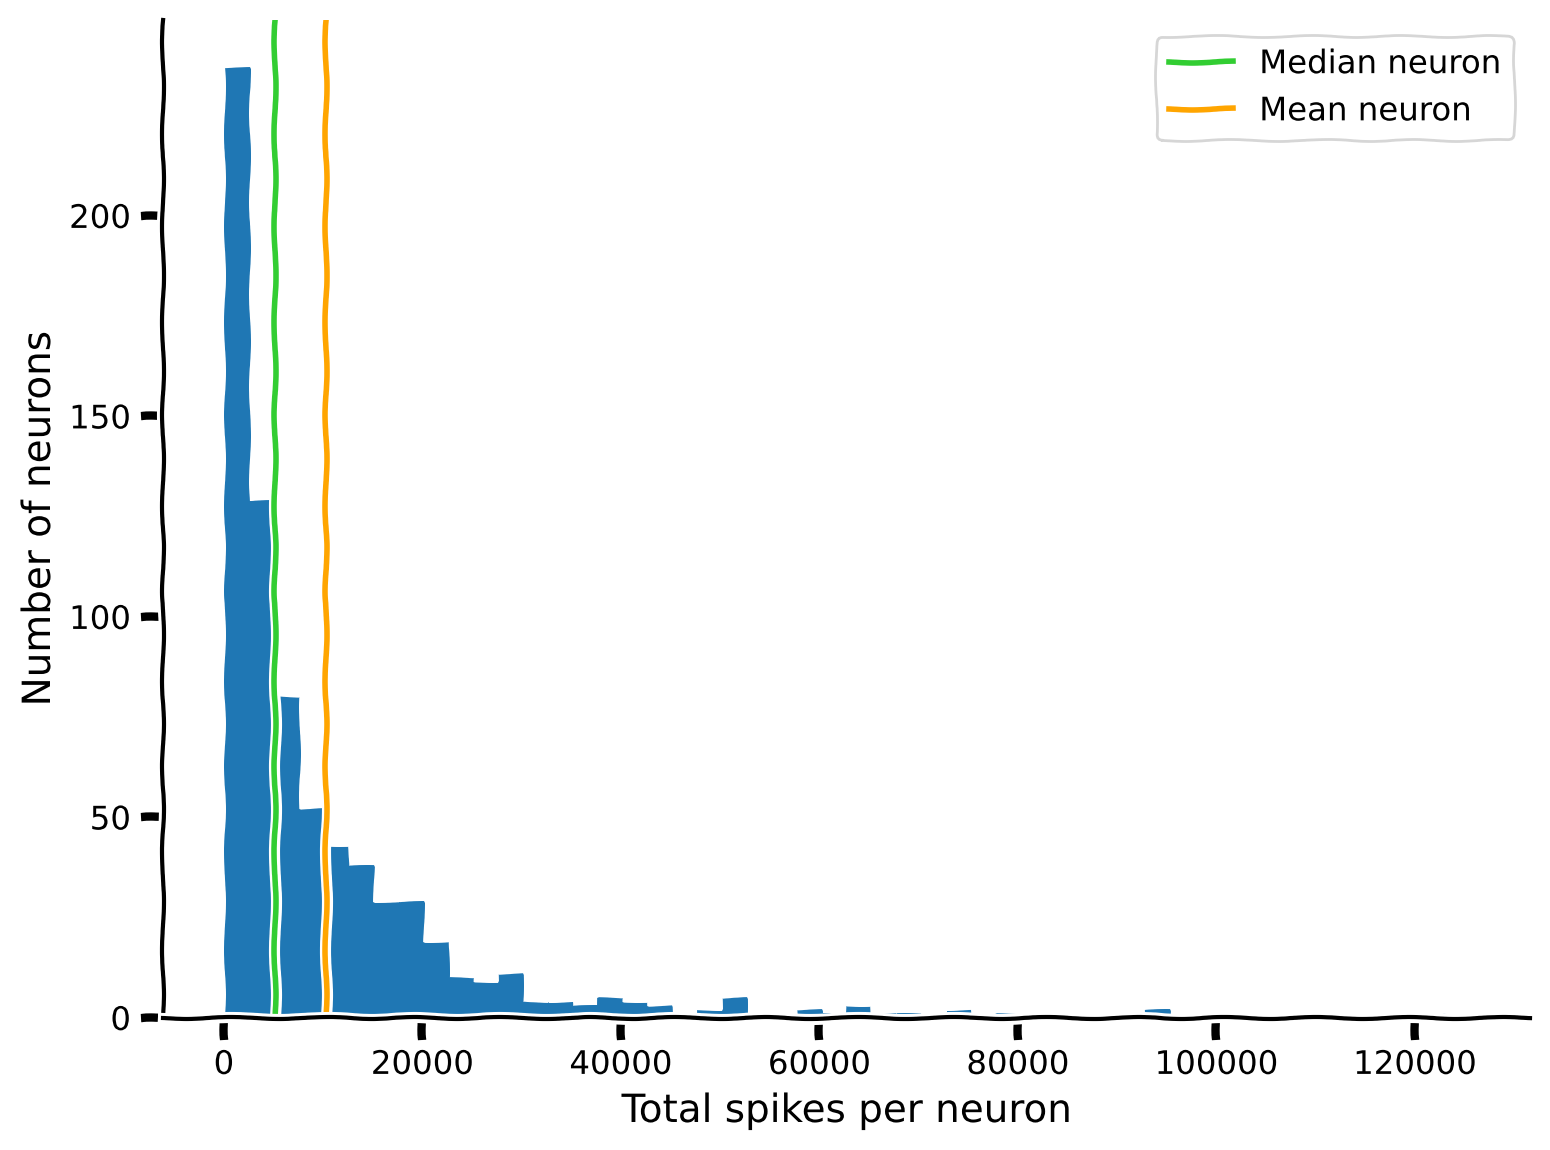

In [5]:

# Compute median spike count
median_spike_count = np.median(total_spikes_per_neuron)  # Hint: Try the function np.median

# Visualize median, mean, and histogram
with plt.xkcd():
  plt.hist(total_spikes_per_neuron, bins=50, histtype="stepfilled")
  plt.axvline(median_spike_count, color="limegreen", label="Median neuron")
  plt.axvline(mean_spike_count, color="orange", label="Mean neuron")
  plt.xlabel("Total spikes per neuron")
  plt.ylabel("Number of neurons")
  plt.legend()

Next, let us define a function to restrict the time of interest to an interval:

In [6]:

# helper function `restrict_spike_times`

def restrict_spike_times(spike_times, interval):
  """Given a spike_time dataset, restrict to spikes within given interval.

  Args:
    spike_times (sequence of np.ndarray): List or array of arrays,
      each inner array has spike times for a single neuron.
    interval (tuple): Min, max time values; keep min <= t < max.

  Returns:
    np.ndarray: like `spike_times`, but only within `interval`
  """
  interval_spike_times = []
  for spikes in spike_times:
    interval_mask = (spikes >= interval[0]) & (spikes < interval[1])
    interval_spike_times.append(spikes[interval_mask])
  return np.array(interval_spike_times, object)


### Define a time interval of interest:

In [7]:

t_interval = (5, 15)  # units are seconds after start of recording
interval_spike_times = restrict_spike_times(spike_times, t_interval)


In [8]:

original_counts = sum([len(spikes) for spikes in spike_times])
interval_counts = sum([len(spikes) for spikes in interval_spike_times])
frac_interval_spikes = interval_counts / original_counts
print(f"{frac_interval_spikes:.2%} of the total spikes are in the interval")


0.33% of the total spikes are in the interval


We can plot the spikes of a single neuron in this time interval:

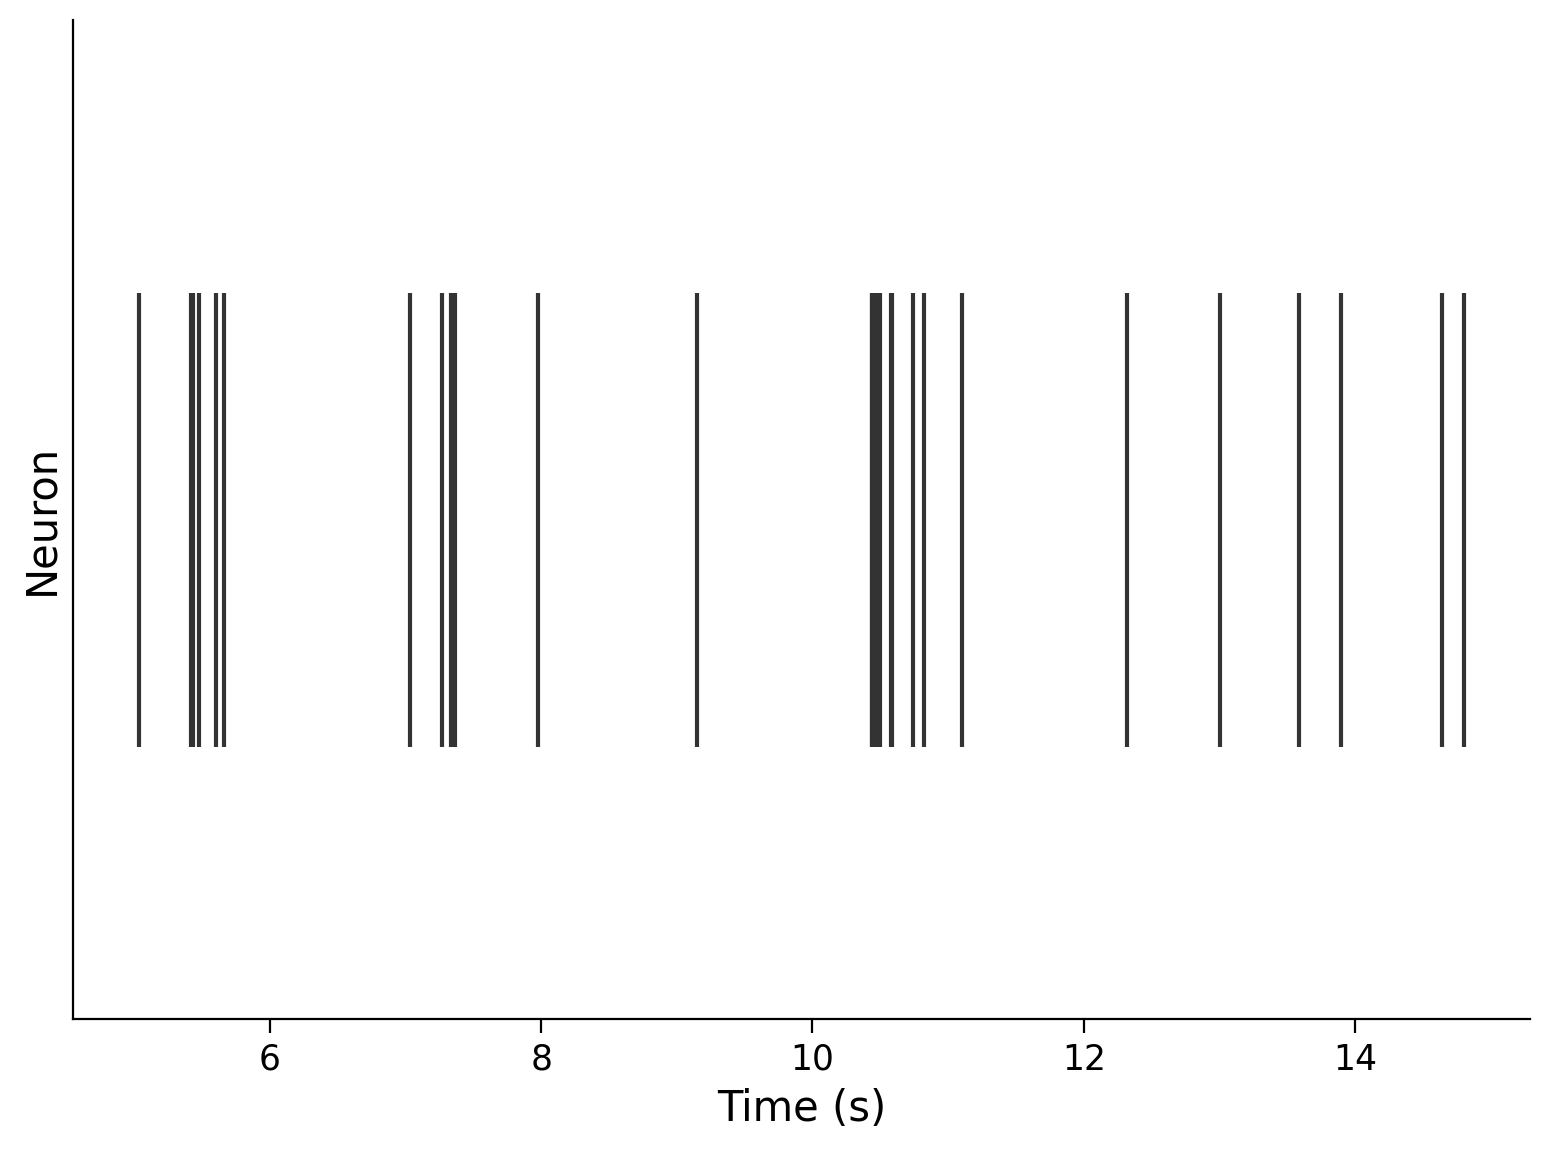

In [9]:

neuron_idx = 1
plt.eventplot(interval_spike_times[neuron_idx], color=".2")
plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.yticks([]);


We can plot the spikes of multiple neurons in this time interval:

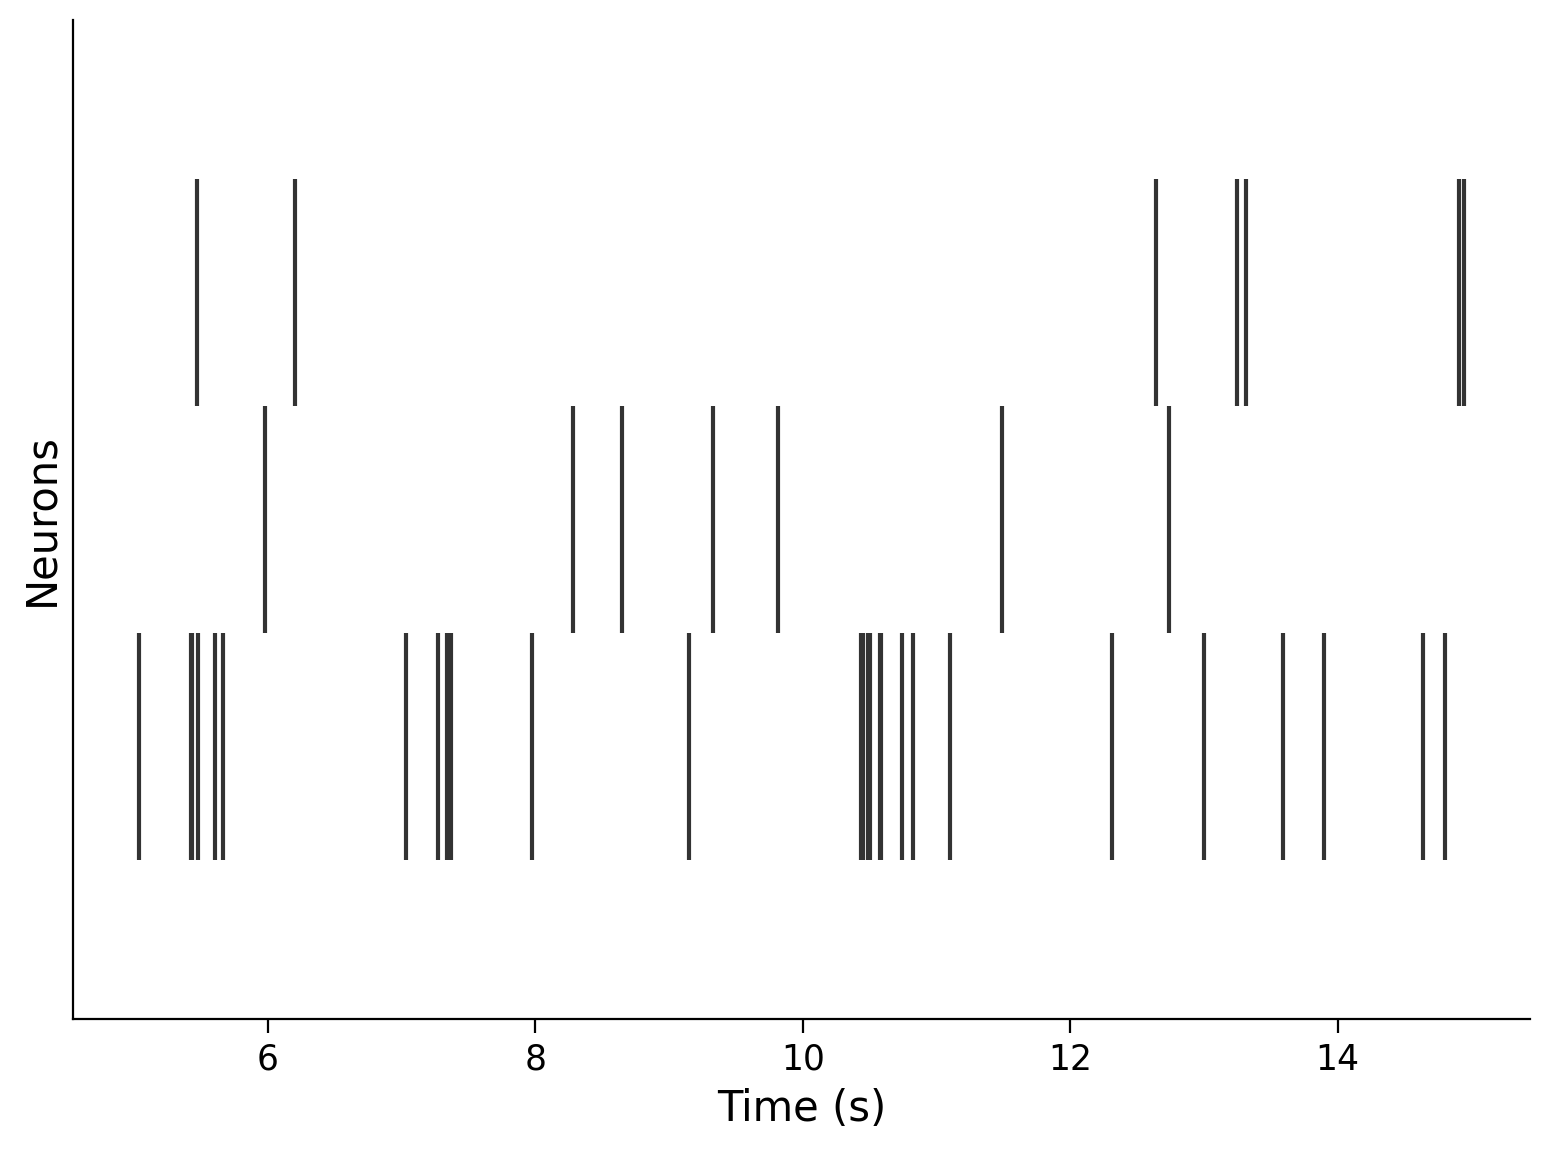

In [10]:

neuron_idx = [1, 11, 100]
plt.eventplot(interval_spike_times[neuron_idx], color=".2")
plt.xlabel("Time (s)")
plt.ylabel("Neurons")
plt.yticks([]);


We can plot the spikes of every one out of five neurons in this time interval:

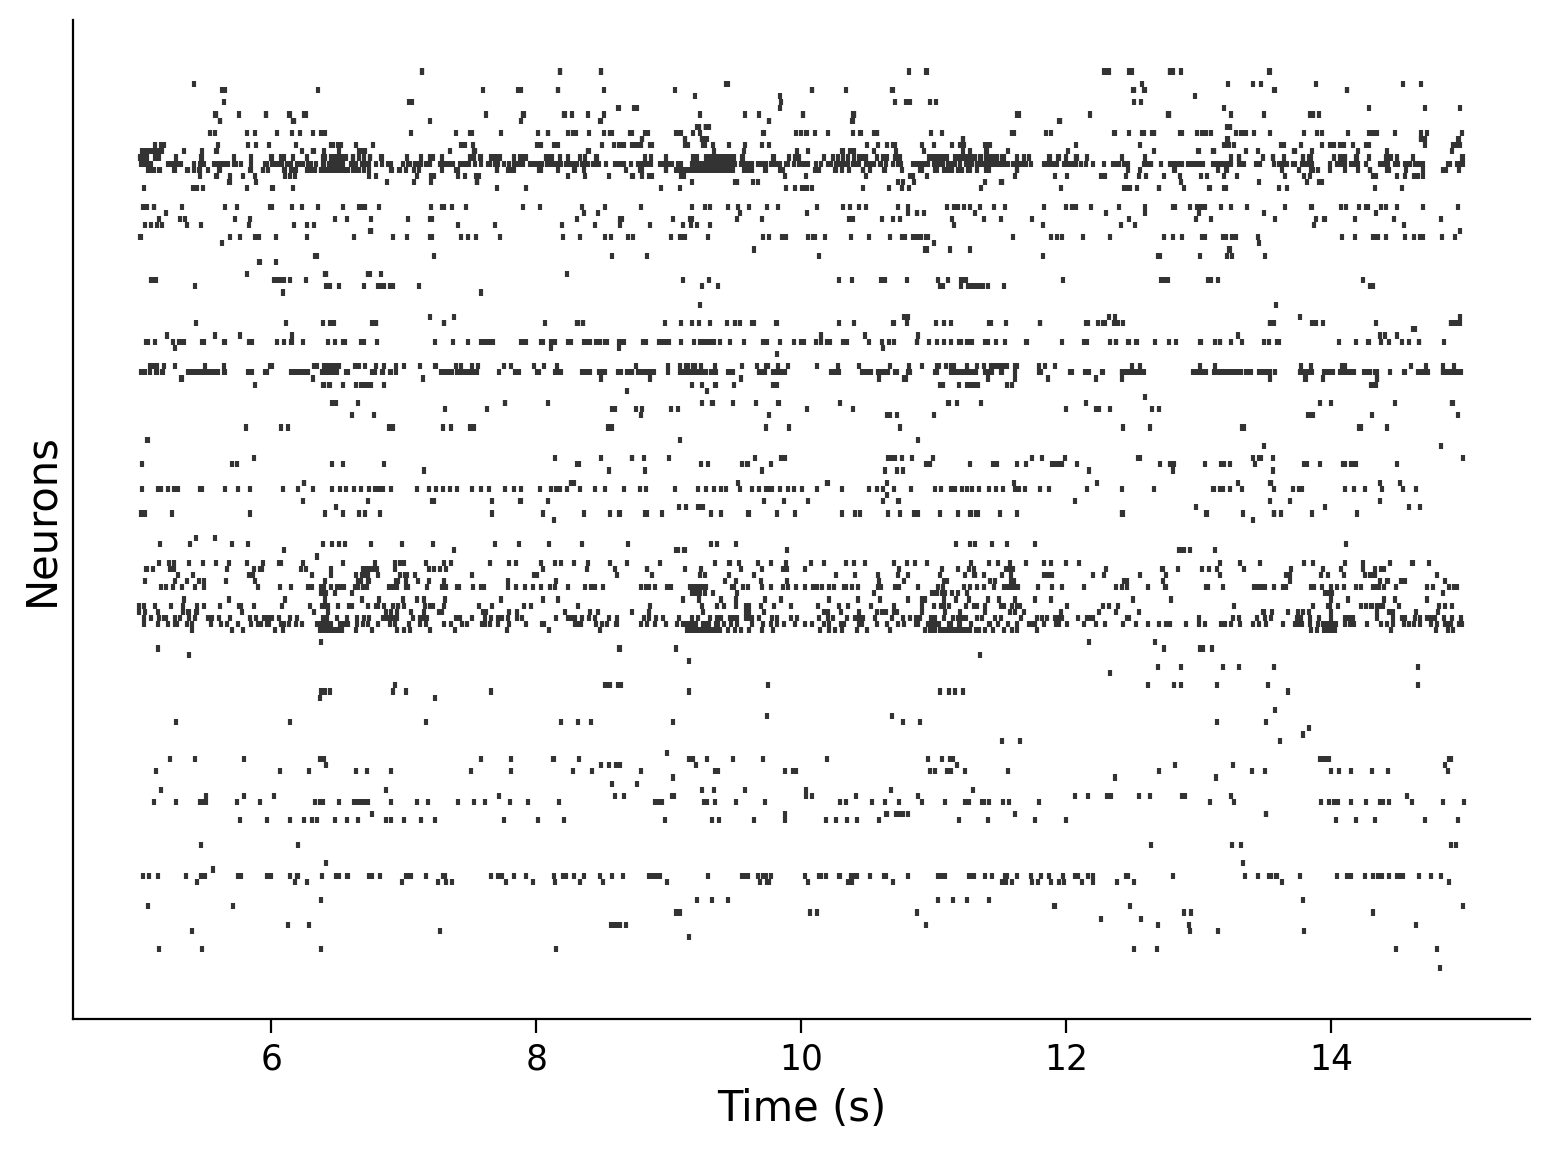

In [11]:

neuron_idx = np.arange(0, len(spike_times), 5)
plt.eventplot(interval_spike_times[neuron_idx], color=".2")
plt.xlabel("Time (s)")
plt.ylabel("Neurons")
plt.yticks([]);


We can also plot the spikes of all neurons in this time interval (it is called a raster plot):

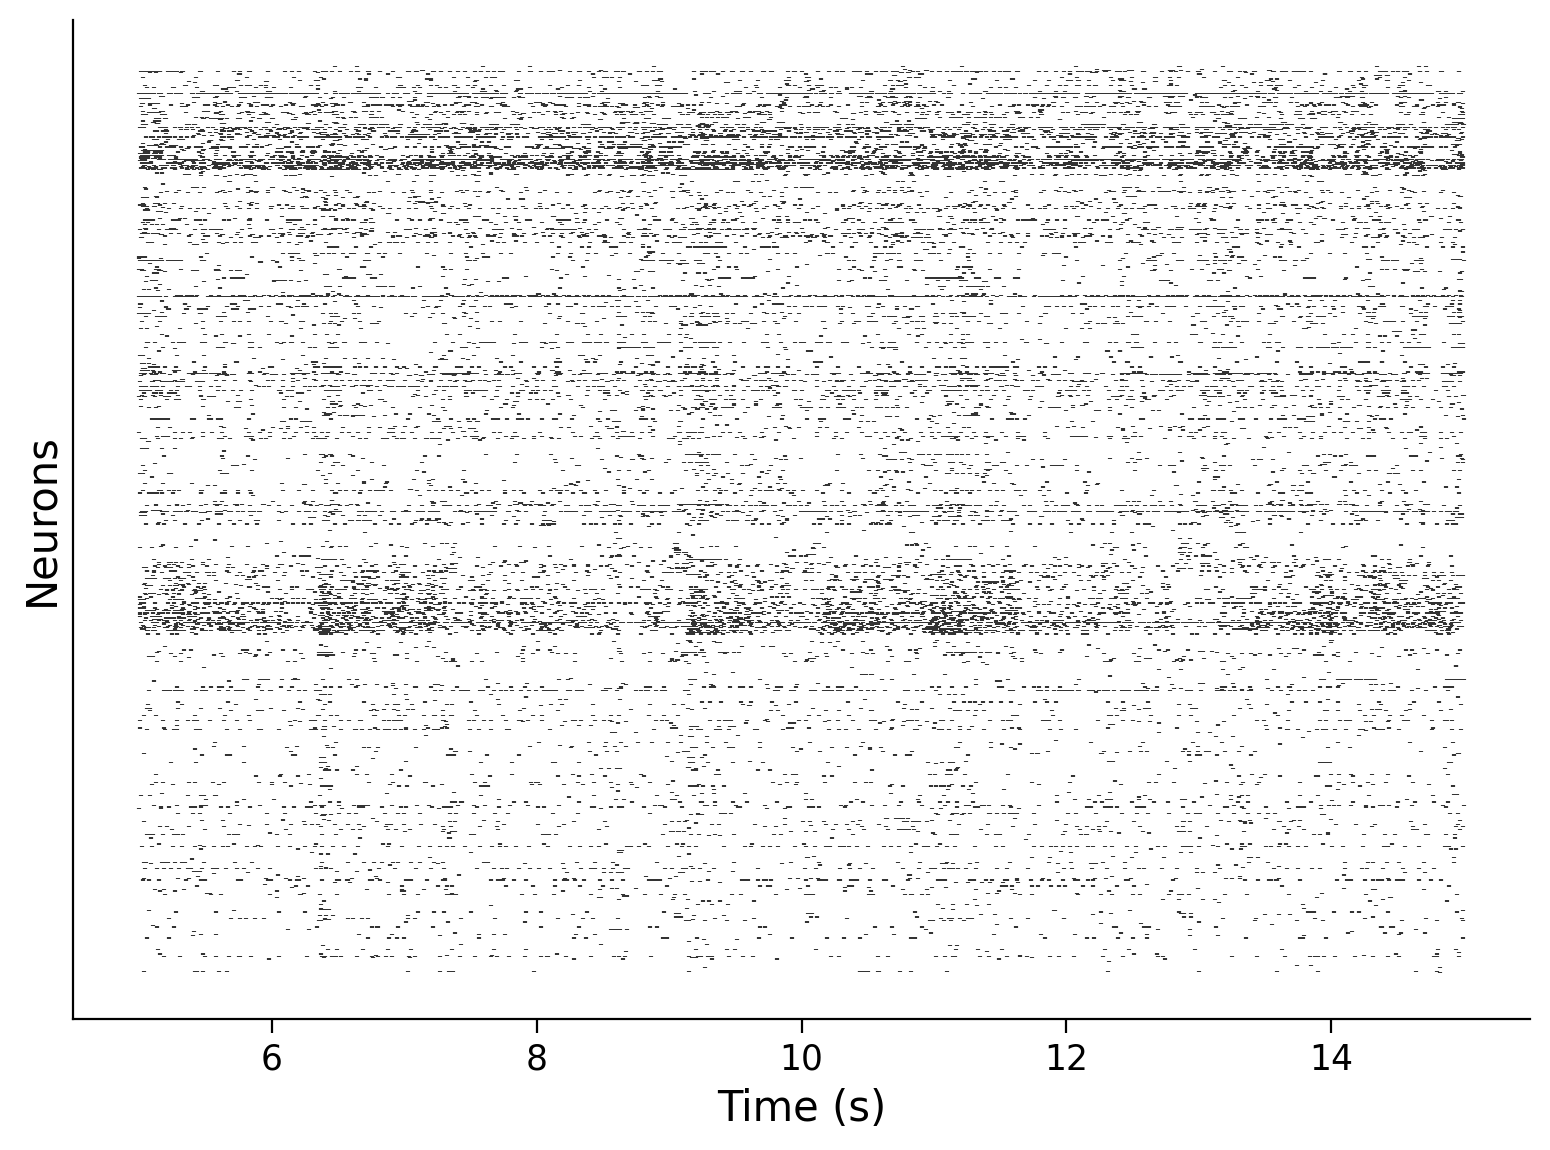

In [12]:

neuron_idx = np.arange(0, len(spike_times), 1)
plt.eventplot(interval_spike_times[neuron_idx], color=".2")
plt.xlabel("Time (s)")
plt.ylabel("Neurons")
plt.yticks([]);


### Inter-Spike Intervals (ISIs)

**Inter-spike intervals (ISIs)** are defined as time differences between consecutive spikes of the same neuron.

First, we need to define a function to compute **inter-spike intervals (ISIs)** of all spikes:

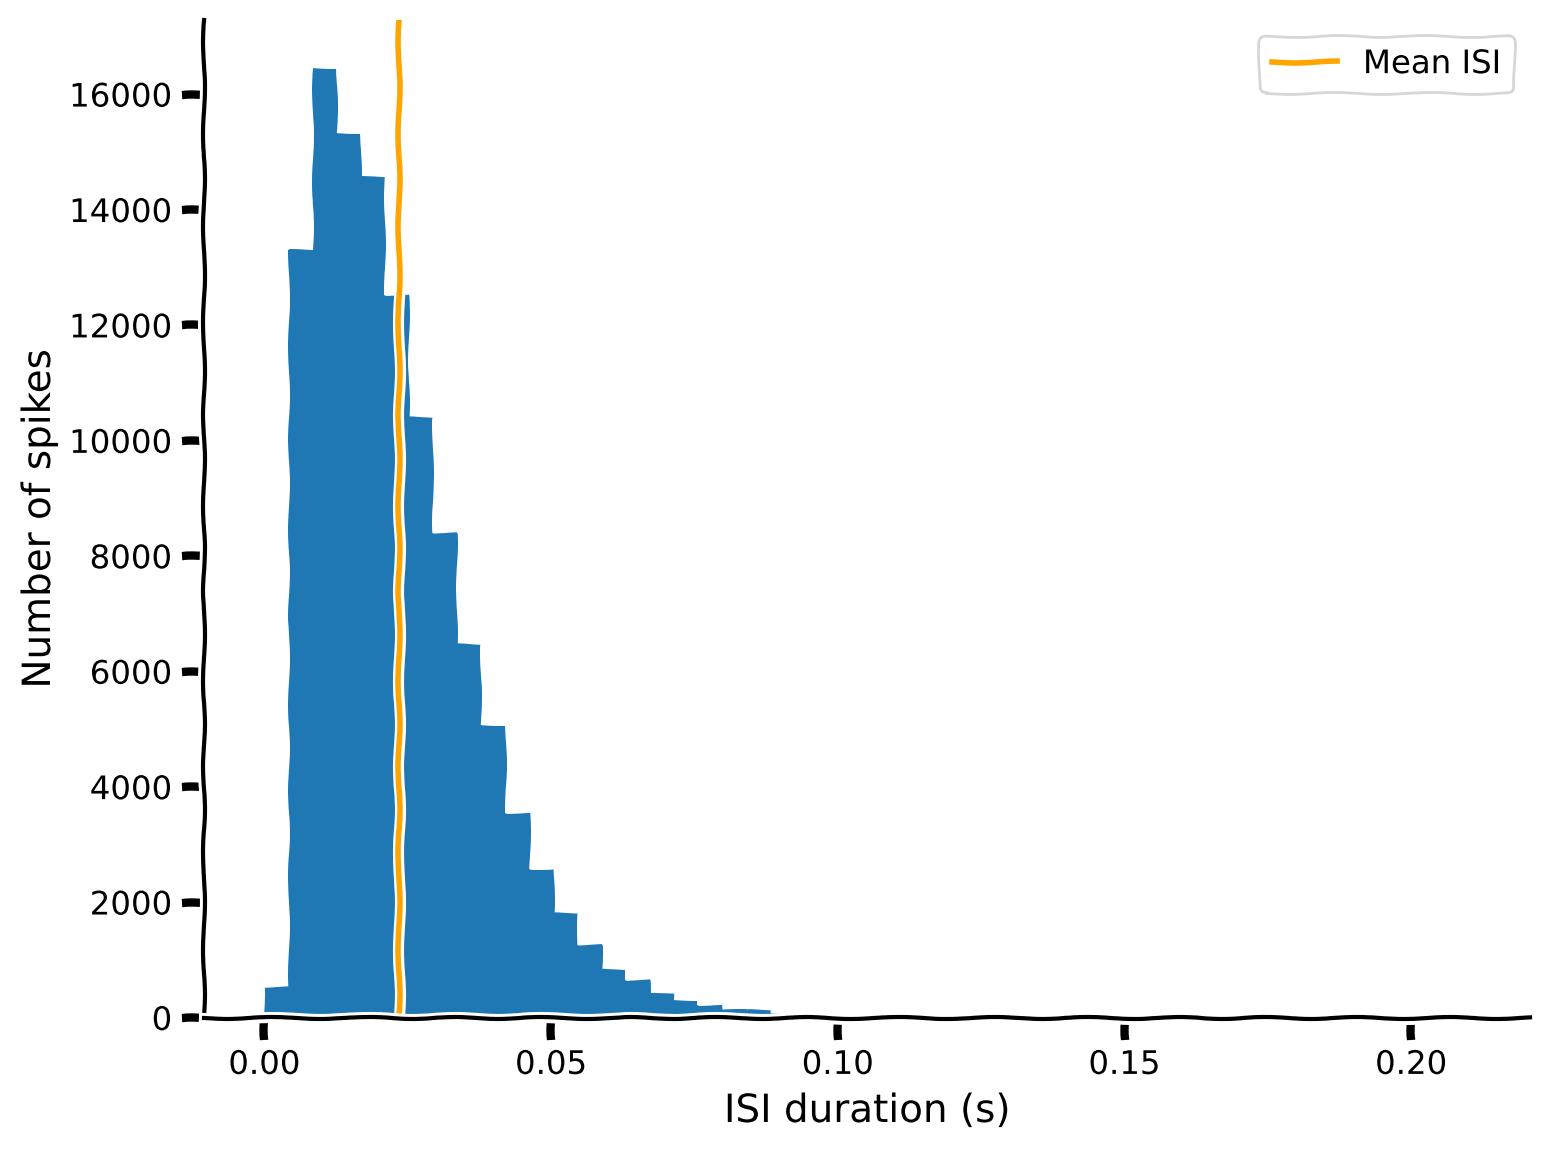

In [13]:

def compute_single_neuron_isis(spike_times, neuron_idx):
  """Compute a vector of ISIs for a single neuron given spike times.

  Args:
    spike_times (list of 1D arrays): Spike time dataset, with the first
      dimension corresponding to different neurons.
    neuron_idx (int): Index of the unit to compute ISIs for.

  Returns:
    isis (1D array): Duration of time between each spike from one neuron.
  """

  # Extract the spike times for the specified neuron
  single_neuron_spikes = spike_times[neuron_idx]

  # Compute the ISIs for this set of spikes
  # Hint: the function np.diff computes discrete differences along an array
  isis = np.diff(single_neuron_spikes)

  return isis

# Compute ISIs
single_neuron_isis = compute_single_neuron_isis(spike_times, neuron_idx=283)

# Visualize ISIs
with plt.xkcd():
  plot_isis(single_neuron_isis)


In [14]:
len(spike_times)

734

In [15]:
def exponential(xs, scale, rate, x0):
  """A simple parameterized exponential function, applied element-wise.

  Args:
    xs (np.ndarray or float): Input(s) to the function.
    scale (float): Linear scaling factor.
    rate (float): Exponential growth (positive) or decay (negative) rate.
    x0 (float): Horizontal offset.

  """
  ys = scale * np.exp(rate * (xs - x0))
  return ys

def inverse(xs, scale, x0):
  """A simple parameterized inverse function (`1/x`), applied element-wise.

  Args:
    xs (np.ndarray or float): Input(s) to the function.
    scale (float): Linear scaling factor.
    x0 (float): Horizontal offset.

  """
  ys = scale / (xs - x0)
  return ys

def linear(xs, slope, y0):
  """A simple linear function, applied element-wise.

  Args:
    xs (np.ndarray or float): Input(s) to the function.
    slope (float): Slope of the line.
    y0 (float): y-intercept of the line.

  """
  ys = slope * xs + y0
  return ys

### What kind of distribution do ISIs follow?

Then we can use the following interactive demo to investigate **ISIs** are following **which kind of probability distribution (linear, inverse, or exponential)**:

In [16]:

single_neuron_idx = 283
single_neuron_spikes = spike_times[single_neuron_idx]
single_neuron_isis = np.diff(single_neuron_spikes)

counts, edges = np.histogram(
  single_neuron_isis,
  bins=50,
  range=(0, single_neuron_isis.max())
)

functions = dict(
  exponential=exponential,
  inverse=inverse,
  linear=linear,
)

colors = dict(
  exponential="C1",
  inverse="C2",
  linear="C4",
)

@widgets.interact(
  exp_scale=widgets.FloatSlider(1000, min=0, max=20000, step=250),
  exp_rate=widgets.FloatSlider(-10, min=-200, max=50, step=1),
  exp_x0=widgets.FloatSlider(0.1, min=-0.5, max=0.5, step=0.005),
  inv_scale=widgets.FloatSlider(1000, min=0, max=3e2, step=10),
  inv_x0=widgets.FloatSlider(0, min=-0.2, max=0.2, step=0.01),
  lin_slope=widgets.FloatSlider(-1e5, min=-6e5, max=1e5, step=10000),
  lin_y0=widgets.FloatSlider(10000, min=0, max=4e4, step=1000),
)
def fit_plot(
  exp_scale=1000, exp_rate=-10, exp_x0=0.1,
  inv_scale=1000, inv_x0=0,
  lin_slope=-1e5, lin_y0=2000,
):
  """Helper function for plotting function fits with interactive sliders."""
  func_params = dict(
    exponential=(exp_scale, exp_rate, exp_x0),
    inverse=(inv_scale, inv_x0),
    linear=(lin_slope, lin_y0),
  )
  f, ax = plt.subplots()
  ax.fill_between(edges[:-1], counts, step="post", alpha=.5)
  xs = np.linspace(1e-10, edges.max())
  for name, function in functions.items():
    ys = function(xs, *func_params[name])
    ax.plot(xs, ys, lw=3, color=colors[name], label=name);
  ax.set(
      xlim=(edges.min(), edges.max()),
      ylim=(0, counts.max() * 1.1),
      xlabel="ISI (s)",
      ylabel="Number of spikes",
  )
  ax.legend()
  plt.show()




interactive(children=(FloatSlider(value=1000.0, description='exp_scale', max=20000.0, step=250.0), FloatSlider…

In this section, we are simply visualizing the data and try to see which kind of probability distribution that the ISIs might be following.

Therefore, we are simply trying to describe the data using **What models**.

## How models

### The linear integrate-and-fire (LIF) model of neurons

How does a neuron spike?

A neuron charges and discharges an electric field across its cell membrane. The state of this electric field can be described by the _membrane potential_. The membrane potential rises due to excitation of the neuron, and when it reaches a threshold a spike occurs. The potential resets, and must rise to a threshold again before the next spike occurs.



One of the simplest models of spiking neuron behavior is the **linear integrate-and-fire (LIF) model** neuron. In this model, the neuron increases its membrane potential $V_m$ over time in response to excitatory input currents $I$ scaled by some factor $\alpha$:

\begin{equation}
dV_m = {\alpha}I
\end{equation}

Once $V_m$ reaches a threshold value a spike is produced, $V_m$ is reset to a starting value, and the process continues.

The input currents $I$ is defined by (Poisson neuron assumption)

$$I \sim \mathrm{Poisson}(\lambda)$$




Here, we will take the starting and threshold potentials as $0$ and $1$, respectively. So, for example, if $\alpha I=0.1$ is constant---that is, the input current is constant---then $dV_m=0.1$, and at each timestep the membrane potential $V_m$ increases by $0.1$ until after $(1-0)/0.1 = 10$ timesteps it reaches the threshold and resets to $V_m=0$, and so on.



Note that we define the membrane potential $V_m$ as a scalar: a single real (or floating point) number. However, a biological neuron's membrane potential will not be exactly constant at all points on its cell membrane at a given time.

The proposed model is a 1D simplification. There are many details we could add to it, to preserve different parts of the complex structure and dynamics of a real neuron. If we were interested in small or local changes in the membrane potential, our 1D simplification could be a problem. However, we'll assume an idealized "point" neuron model for our current purpose.

First, we need to compute $dV_m$:  



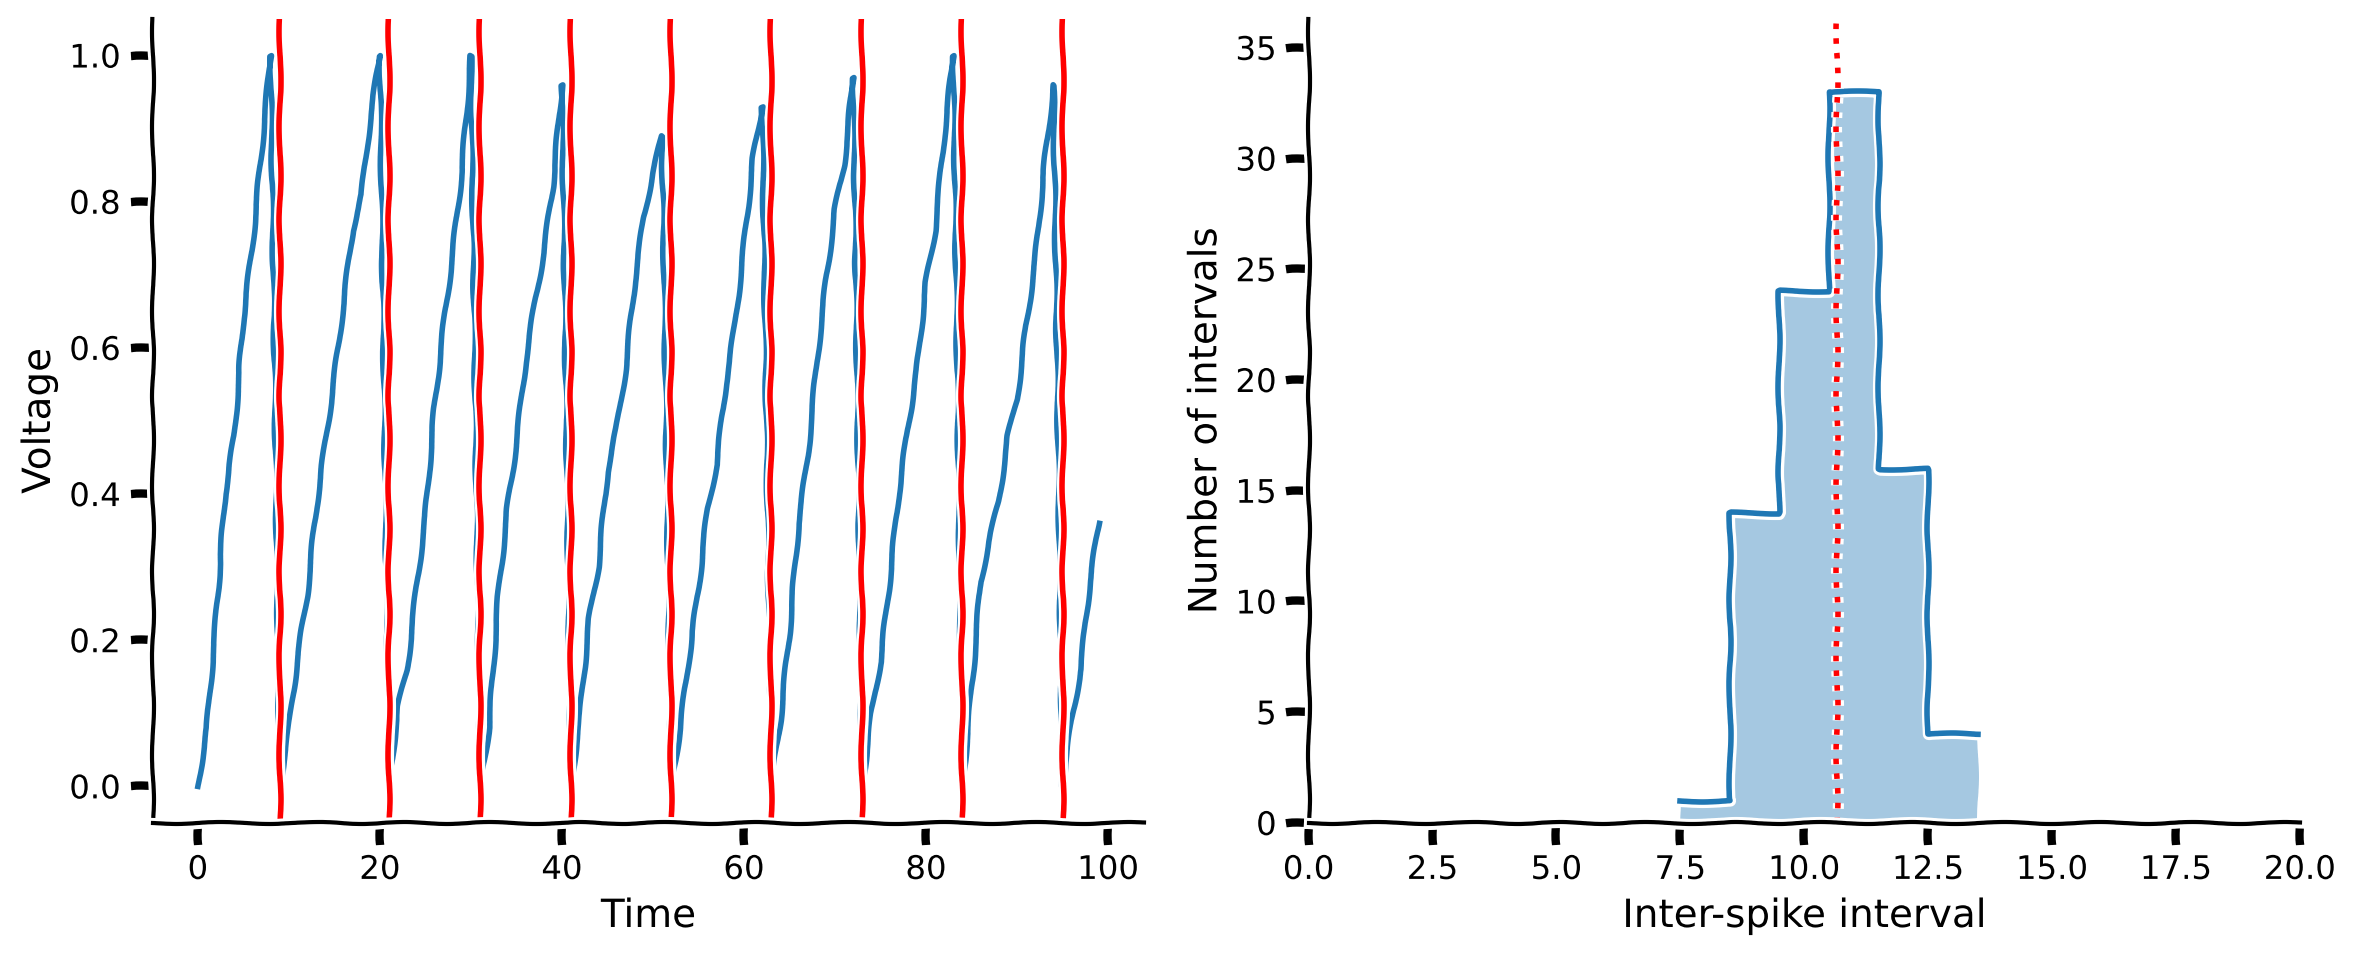

In [17]:

def lif_neuron(n_steps=1000, alpha=0.01, rate=10):
  """ Simulate a linear integrate-and-fire neuron.

  Args:
    n_steps (int): The number of time steps to simulate the neuron's activity.
    alpha (float): The input scaling factor
    rate (int): The mean rate of incoming spikes

  """
  # Precompute Poisson samples for speed
  exc = stats.poisson(rate).rvs(n_steps)

  # Initialize voltage and spike storage
  v = np.zeros(n_steps)
  spike_times = []

  # Loop over steps
  for i in range(1, n_steps):

    # Update v
    dv = alpha * exc[i]
    v[i] = v[i-1] + dv

    # If spike happens, reset voltage and record
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0

  return v, spike_times

# Set random seed (for reproducibility)
np.random.seed(12)

# Model LIF neuron
v, spike_times = lif_neuron()

# Visualize
with plt.xkcd():
  plot_neuron_stats(v, spike_times)

In [18]:

exc = stats.poisson(10).rvs(20)
exc

array([11, 18,  3,  9, 10, 14, 10,  8, 10,  9, 14,  9, 12,  8, 14, 11, 16,
        7, 12,  3])

# Question #1

You can now explore how various parameters of the LIF model influence the ISI distribution. Specifically, you can vary alpha, which is input scaling factor, and rate, which is the mean rate of incoming spikes.

1. What is the spiking pattern of this model?

2. What effect does raising or lowering alpha have?

3. What effect does raising or lowering the rate have?

4. Does the distribution of ISIs ever look like what you observed in the data in the What models section?

Please answer below:

1. Bell-shaped
2. Increasing alpha increases the spike intervals and the ISIs distribution shifts to the left indicating decreasing interval between spikes
3. Increasing rate also increases the spike intervals and the ISIs distribution shifts to the left indicating decreasing interval between spikes
4. No, it is more uniform and bell-shaped whereas in the what model it was more of exponential prob. distribution

In [20]:

def _lif_neuron(n_steps=1000, alpha=0.01, rate=10):
  exc = stats.poisson(rate).rvs(n_steps)
  v = np.zeros(n_steps)
  spike_times = []
  for i in range(1, n_steps):
    dv = alpha * exc[i]
    v[i] = v[i-1] + dv
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0
  return v, spike_times

@widgets.interact(
  alpha=widgets.FloatLogSlider(0.01, min=-2, max=-1),
  rate=widgets.IntSlider(10, min=5, max=20)
)
def plot_lif_neuron(alpha=0.01, rate=10):
  v, spike_times = _lif_neuron(2000, alpha, rate)

  plot_neuron_stats(v, spike_times)

interactive(children=(FloatLogSlider(value=0.01, description='alpha', max=-1.0, min=-2.0), IntSlider(value=10,…

### The leaky linear integrate-and-fire (LIF) with inhibition model  

Our linear integrate-and-fire neuron from the previous section was indeed able to produce spikes. However, our ISI histogram doesn't look much like empirical ISI histograms seen in the What models section, which had an exponential-like shape. What is our model neuron missing, given that it doesn't behave like a real neuron?

In the previous model we only considered excitatory behavior -- the only way the membrane potential could decrease was upon a spike event. We know, however, that there are other factors that can drive $V_m$ down. First is the natural tendency of the neuron to return to some steady state or resting potential. We can update our previous model as follows:

\begin{equation}
dV_m = -{\beta}V_m + {\alpha}I
\end{equation}

where $V_m$ is the current membrane potential and $\beta$ is some leakage factor. This is a basic form of the popular Leaky Integrate-and-Fire model neuron.

We also know that in addition to excitatory presynaptic neurons, we can have inhibitory presynaptic neurons as well. We can model these inhibitory neurons with another Poisson random variable:

\begin{align}
I &= I_{\mathrm{exc}} - I_{\mathrm{inh}} \\
I_{\mathrm{exc}} &\sim \mathrm{Poisson}(\lambda_{\mathrm{exc}}) \\
I_{\mathrm{inh}} &\sim \mathrm{Poisson}(\lambda_{\mathrm{inh}})
\end{align}

where $\lambda_{\mathrm{exc}}$ and $\lambda_{\mathrm{inh}}$ are the average spike rates (per timestep) of the excitatory and inhibitory presynaptic neurons, respectively.

Then we need to write the code to compute the change in voltage $dV_m$ of the leaky LIF model neuron with inhibition described above:  

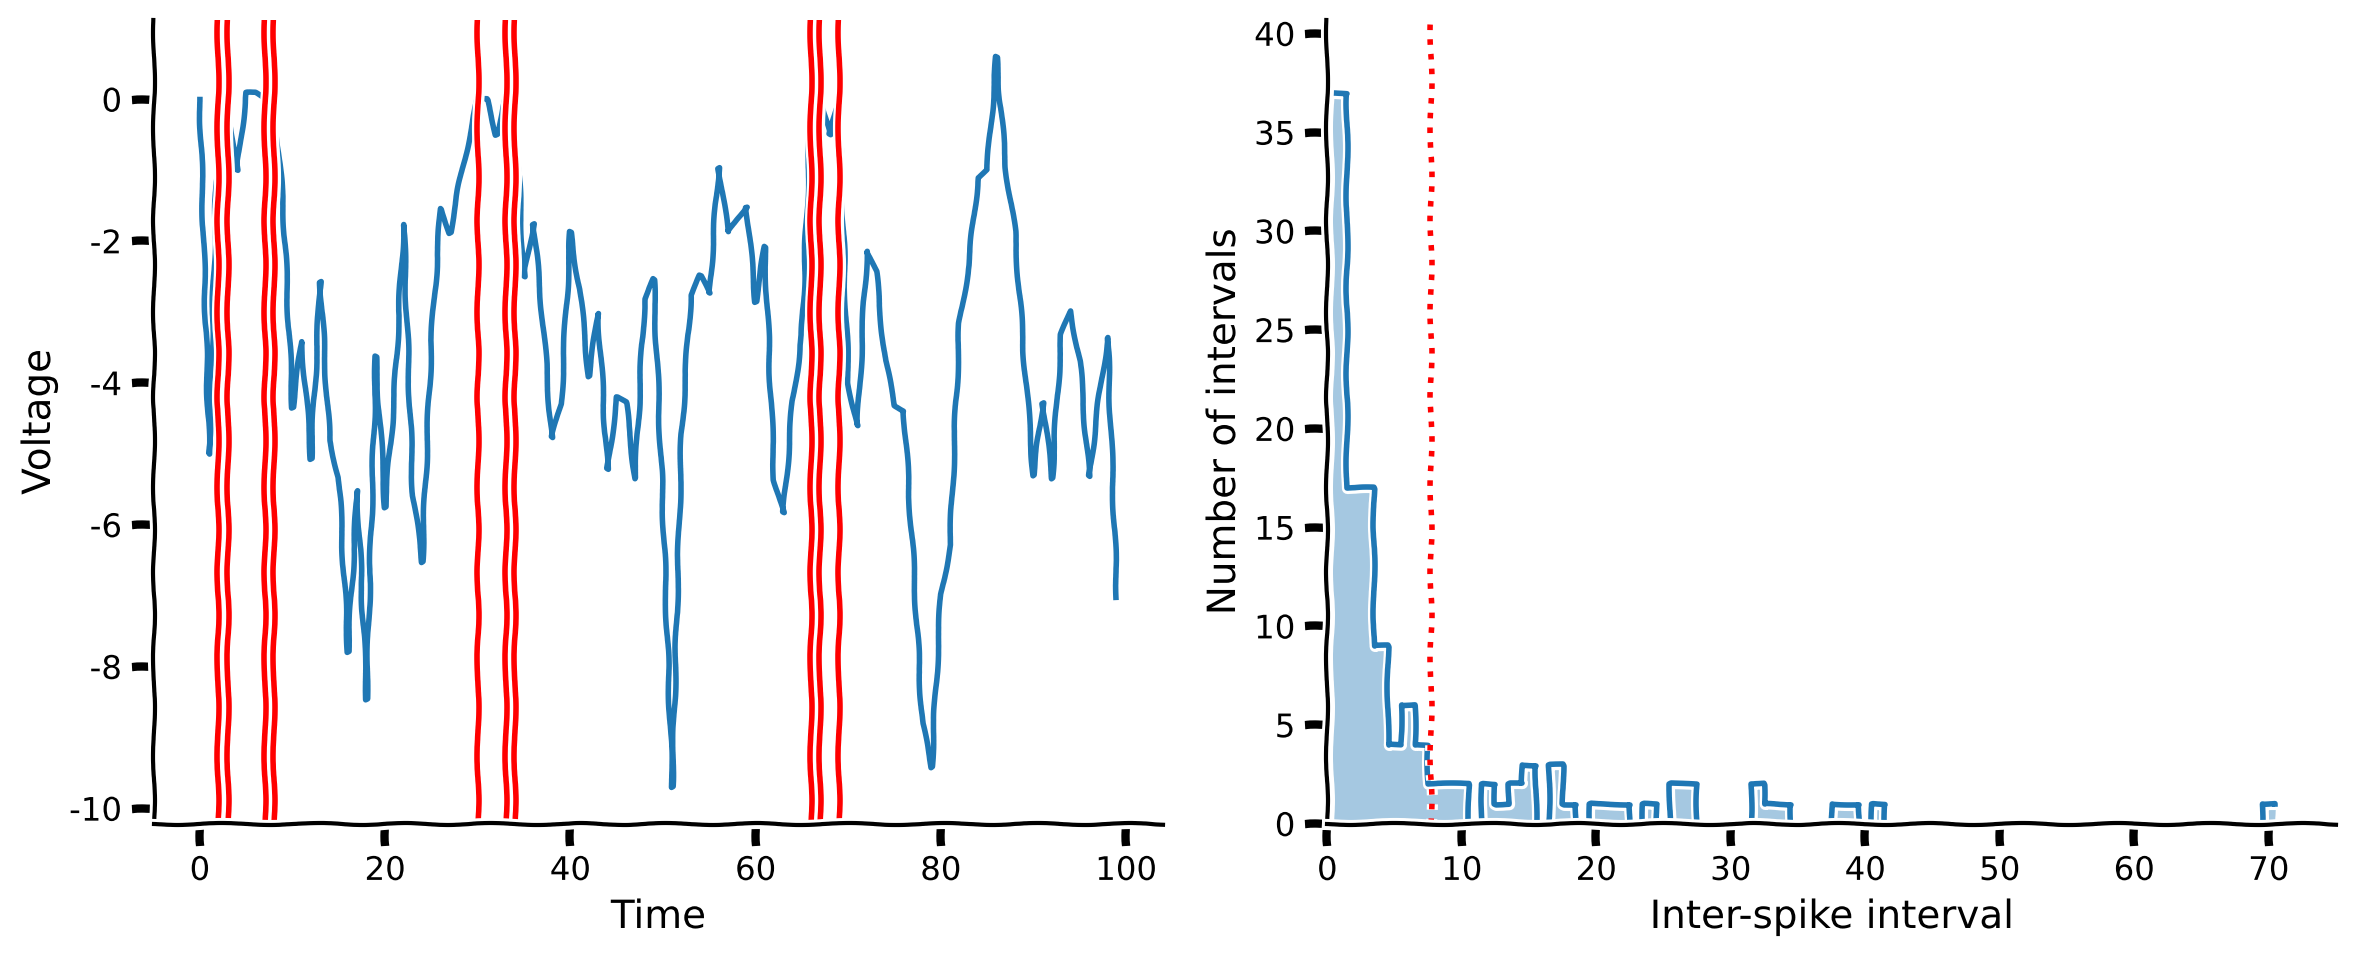

In [21]:

def lif_neuron_inh(n_steps=1000, alpha=0.5, beta=0.1, exc_rate=10, inh_rate=10):
  """ Simulate a simplified leaky integrate-and-fire neuron with both excitatory
  and inhibitory inputs.

  Args:
    n_steps (int): The number of time steps to simulate the neuron's activity.
    alpha (float): The input scaling factor
    beta (float): The membrane potential leakage factor
    exc_rate (int): The mean rate of the incoming excitatory spikes
    inh_rate (int): The mean rate of the incoming inhibitory spikes
  """
  # precompute Poisson samples for speed
  exc = stats.poisson(exc_rate).rvs(n_steps)
  inh = stats.poisson(inh_rate).rvs(n_steps)

  v = np.zeros(n_steps)
  spike_times = []
  for i in range(1, n_steps):

    dv = -beta * v[i-1] + alpha * (exc[i] - inh[i])

    v[i] = v[i-1] + dv
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0

  return v, spike_times

# Set random seed (for reproducibility)
np.random.seed(12)

# Model LIF neuron
v, spike_times = lif_neuron_inh()

# Visualize
with plt.xkcd():
  plot_neuron_stats(v, spike_times)



# Question #2

You can play with the parameters of the input to our LIF neuron and visualize what happens. Here, in addition to controlling `alpha`, which scales the input, you can also control `beta`, which is a leakage factor on the voltage, `exc_rate`, which is the mean rate of the excitatory presynaptic neurons, and `inh_rate`, which is the mean rate of the inhibitory presynaptic neurons.

1.   What effect does raising the excitatory rate have?
2.   What effect does raising the inhibitory rate have?
3.   What if you raise both the excitatory and inhibitory rate?
4.   Does the distribution of ISIs ever look like what you observed in the data in the What models section?

Please answer below:
1. Increasing the excitatory rate increases the spike intervals and the ISIs distribution shifts to the left indicating decreasing interval between spikes
2. Increasing the inhibitory rate decreases the spikes as the voltage barely goes past threshold
3. When both are increasing, initially the spike increase due to increase in exc rate is nullified by the inh rate, however as both the rates are increased to the max there is still some spikes and the ISIs pattern is more of exponential-like
4. Yes, mainly when exc rate is high and inh rate is low

In [22]:

def _lif_neuron_inh(n_steps=1000, alpha=0.5, beta=0.1, exc_rate=10, inh_rate=10):
  """ Simulate a simplified leaky integrate-and-fire neuron with both excitatory
  and inhibitory inputs.

  Args:
    n_steps (int): The number of time steps to simulate the neuron's activity.
    alpha (float): The input scaling factor
    beta (float): The membrane potential leakage factor
    exc_rate (int): The mean rate of the incoming excitatory spikes
    inh_rate (int): The mean rate of the incoming inhibitory spikes
  """
  # precompute Poisson samples for speed
  exc = stats.poisson(exc_rate).rvs(n_steps)
  inh = stats.poisson(inh_rate).rvs(n_steps)

  v = np.zeros(n_steps)
  spike_times = []
  for i in range(1, n_steps):
    dv = alpha * (exc[i] - inh[i]) # - beta * v[i-1]
    v[i] = v[i-1] + dv
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0

  return v, spike_times

@widgets.interact(alpha=widgets.FloatLogSlider(0.5, min=-2, max=1),
                  beta=widgets.FloatLogSlider(0.1, min=-1, max=0),
                  exc_rate=widgets.IntSlider(12, min=0, max=20),
                  inh_rate=widgets.IntSlider(12, min=0, max=20))
def plot_lif_neuron(alpha=0.5, beta=0.1, exc_rate=10, inh_rate=10):
  v, spike_times = _lif_neuron_inh(2000, alpha, beta, exc_rate, inh_rate)
  plot_neuron_stats(v, spike_times)

interactive(children=(FloatLogSlider(value=0.5, description='alpha', max=1.0, min=-2.0), FloatLogSlider(value=…

## Why models

**Why ISIs seems to be following an exponential distribution?**

### Entropy

The concept of entropy originated in thermodynamics, introduced by the German physicist Rudolf Clausius in the mid-19th century. Clausius developed the term while studying the efficiency of heat engines and the irreversible nature of heat transfer. The macroscopic definition of entropy given by Clausius is:

$$\Delta S = \int \frac{\delta Q_{\text{rev}}}{T} \text{   (Clausius entropy)}$$  

Where $\Delta S$ is the change of entropy in the system,

$Q_{\text{rev}}$ is the infinitesimal reversible heat transfer into the system,

$T$ is temperature of the system.



Later, Ludwig Boltzmann found that the equivalent microscopic, statistical interpretation of entropy is:

$$S = k_B \ln \Omega \text{   (Boltzmann entropy)}$$  

Where $S$ is entropy,

$k_B$ is Boltzmann constant (It is used to assign a unit e.g. $J/K$ to entropy in physics. Entropy have other units in other areas outside of physics, so $k_B$ is usually removed when talking about entropy in information theory, statistics, neuroscience, etc. For example, the unit of entropy is usually bit in information theory)

$\Omega$ is the number of possible microstates consistent with the macroscopic state. For example, when there are 10 identical balls in total (macroscopic state), $\Omega$ could be the number of possible ways to put them into 2 boxes (1 ball and 9 balls, 2 balls and 8 balls, etc.).



Over time, the statistical interpretation of entropy has been adapted and extended to other fields, including statistical mechanics and information theory.

$$S = \log \Omega$$  

In order to calculate the entropy of probability distributions, Claude Shannon gives another mathematically equivalent definition of entropy:

$$H = -\sum_{i=1}^n p(x_i) \log p(x_i)  \text{   (Shannon entropy)}$$

Where $H$ is entropy,

$p(x_i)$ is the probability of the i-th outcome of random variable $X$, (when probability distribution is discrete)

$n$ is the number of possible outcomes, (when probability distribution is discrete)



The base of the logarithm in entropy can have many different choices. It is usually $e$ in physics, and it is usually 2 in many other areas including information theory and computational neuroscience.



**All of the above definitions of entropy (Clausius entropy, Boltzmann entropy, Shannon entropy) can be proved to be mathematically equivalent**.

Therefore, entropy in physics, information theory, computer science, statistics, and computational neuroscience is the same mathematical quantity expressed in different units and applied in different contexts.  



### What does entropy mean? Why do we need the concept of entropy?

**Entropy can tell us the degree of our ignorance about a system.**



For example:

When we are flipping a coin, the coin could be a fair coin or a biased coin.



1. **Fair Coin (Maximal Ignorance)**

Probability of heads = 0.5

Probability of tails = 0.5

$$ H = -(0.5\log0.5 + 0.5\log0.5) = 1 \; bit $$

Interpretation: We have no prior knowledge favoring heads or tails, so our uncertainty (or ignorance) about the outcome is as large as it can be for two possibilities.



2. **Biased Coin (Less Ignorance)**

Probability of heads = 0.8

Probability of tails = 0.2

$$ H = -(0.2\log0.2 + 0.8\log0.8) ≈ 0.72 \; bits < 1 \; bit $$

Interpretation: Because heads is more likely, we have some knowledge of the outcome in advance. Our ignorance of the system is smaller than in the fair-coin case.



3. **Degenerate Case (No Ignorance)**

Probability of heads = 1.0

Probability of tails = 0.0

$$ H = -(0\log0 + 1\log1) = 0 \; bit $$

Interpretation: If the coin always comes up heads, we already know the result. There is zero uncertainty and we have no ignorance of the system, hence entropy is 0.

### Compute the entropy of a probability distribution

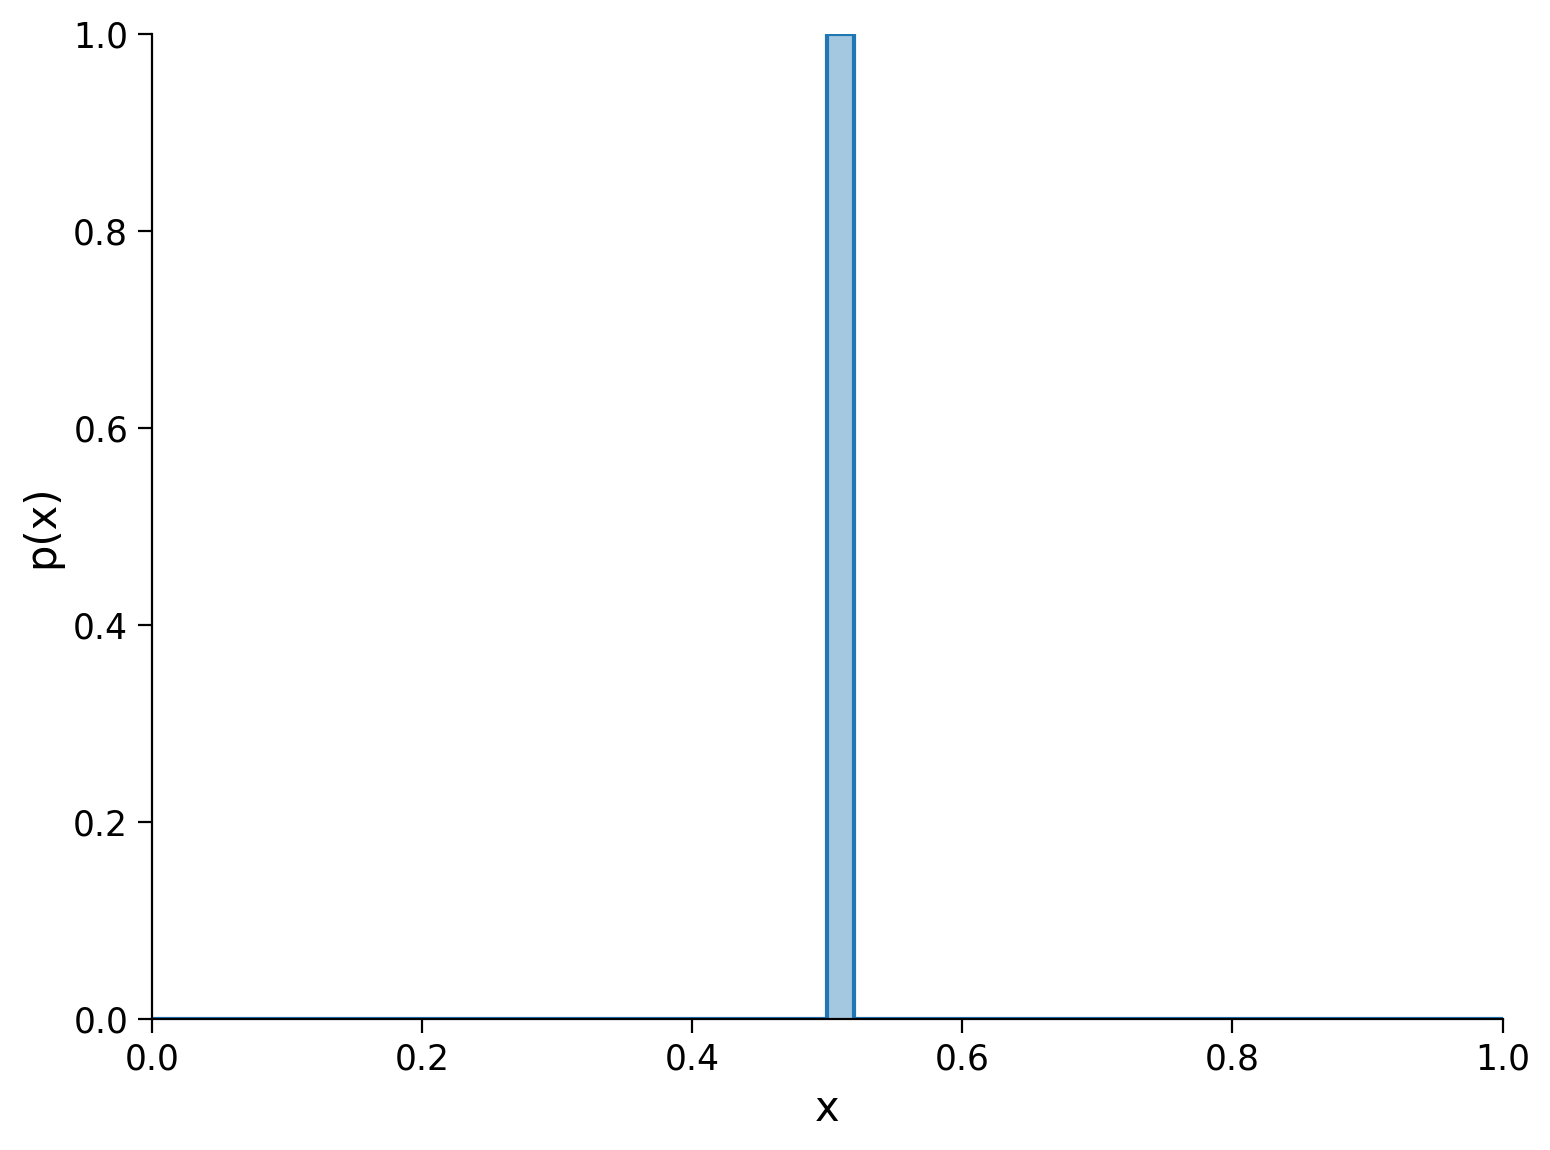

In [23]:

n_bins = 50  # number of points supporting the distribution
x_range = (0, 1)  # will be subdivided evenly into bins corresponding to points

bins = np.linspace(*x_range, n_bins + 1)  # bin edges

pmf = np.zeros(n_bins)
pmf[len(pmf) // 2] = 1.0  # middle point has all the mass

# Since we already have a PMF, rather than un-binned samples, `plt.hist` is not
# suitable. Instead, we directly plot the PMF as a step function to visualize
# the histogram:
pmf_ = np.insert(pmf, 0, pmf[0])  # this is necessary to align plot steps with bin edges
plt.plot(bins, pmf_, drawstyle="steps")
# `fill_between` provides area shading
plt.fill_between(bins, pmf_, step="pre", alpha=0.4)
plt.xlabel("x")
plt.ylabel("p(x)")
plt.xlim(x_range)
plt.ylim(0, 1)
plt.show()

What is the entropy of the probability distribution shown above? Complete the following coding exercise to compute it.

In [24]:

def entropy(pmf):
  """Given a discrete distribution, return the Shannon entropy in bits.

  This is a measure of information in the distribution. For a totally
  deterministic distribution, where samples are always found in the same bin,
  then samples from the distribution give no more information and the entropy
  is 0.

  For now this assumes `pmf` arrives as a well-formed distribution (that is,
  `np.sum(pmf)==1` and `not np.any(pmf < 0)`)

  Args:
    pmf (np.ndarray): The probability mass function for a discrete distribution
      represented as an array of probabilities.
  Returns:
    h (number): The entropy of the distribution in `pmf`.
  """
  # reduce to non-zero entries to avoid an error from log2(0)
  pmf = pmf[pmf > 0]

  # implement the equation for Shannon entropy (in bits)
  h = -np.sum(pmf * np.log2(pmf))

  # return the absolute value (avoids getting a -0 result)
  return np.abs(h)

# Call entropy function and print result
print(f"{entropy(pmf):.2f} bits")

0.00 bits


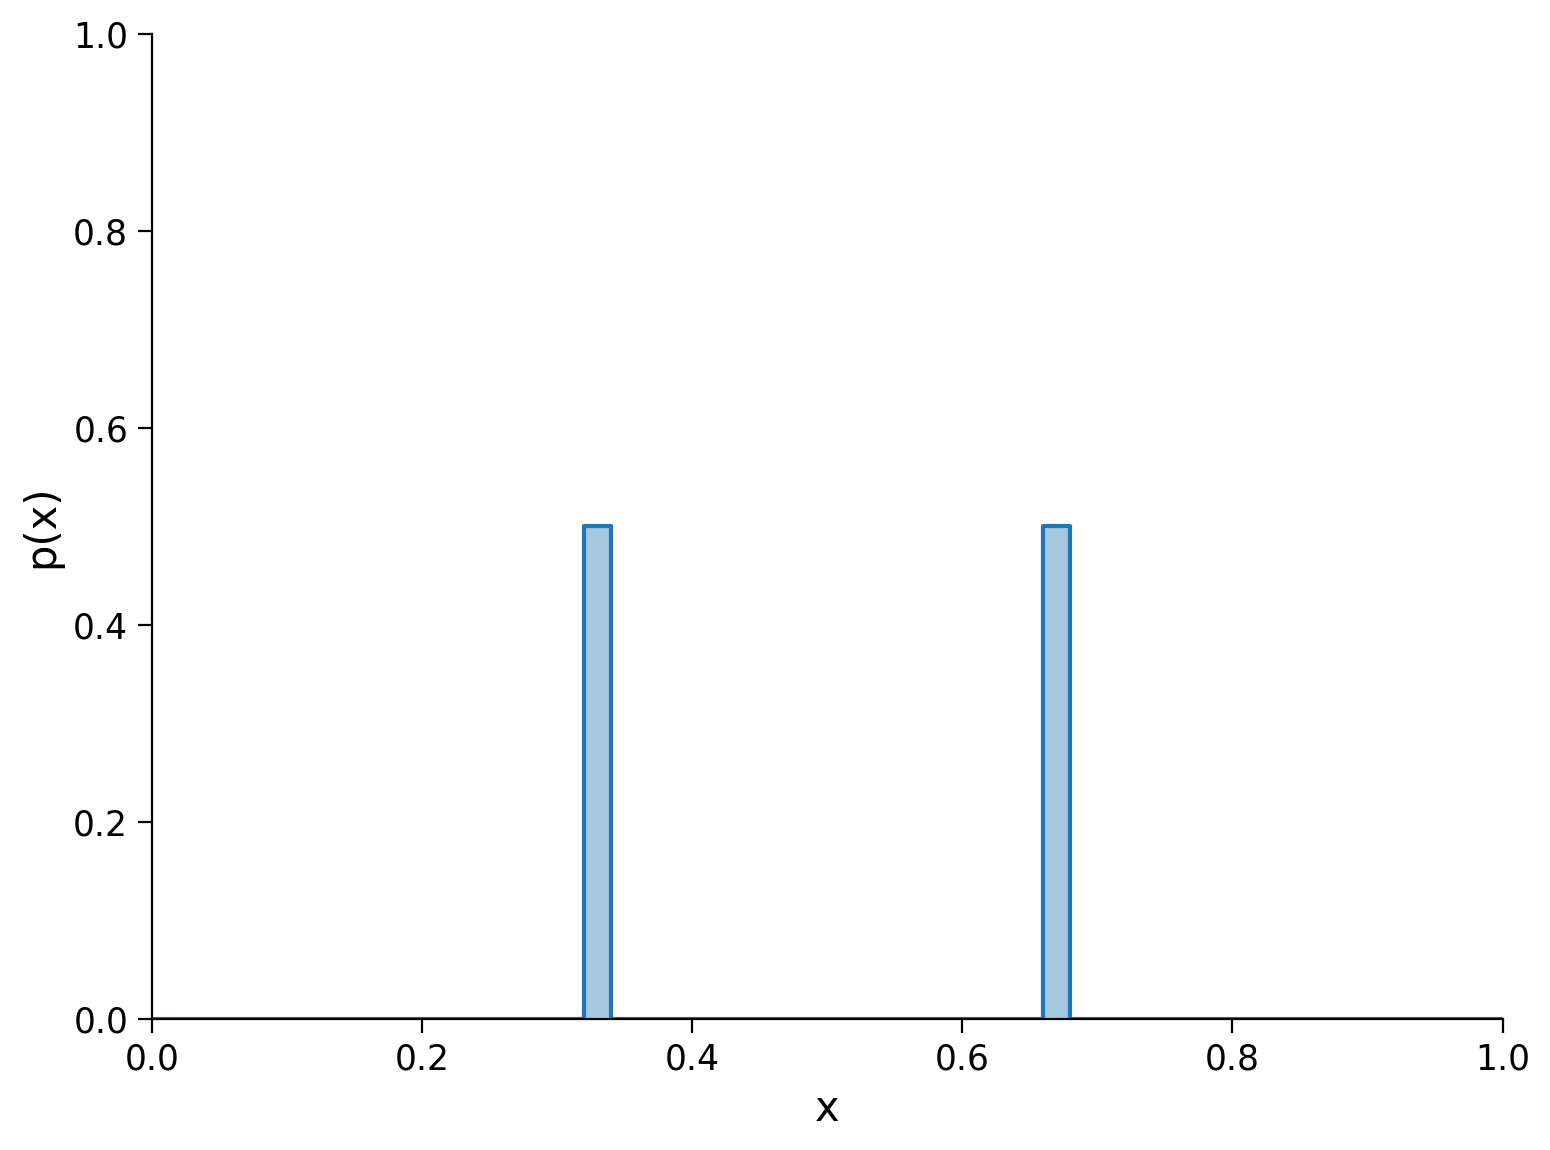

In [25]:

pmf = np.zeros(n_bins)
pmf[len(pmf) // 3] = 0.5
pmf[2 * len(pmf) // 3] = 0.5

pmf_ = np.insert(pmf, 0, pmf[0])
plt.plot(bins, pmf_, drawstyle="steps")
plt.fill_between(bins, pmf_, step="pre", alpha=0.4)
plt.xlabel("x")
plt.ylabel("p(x)")
plt.xlim(x_range)
plt.ylim(0, 1)
plt.show()

What is the entropy of the probability distribution shown above?

In [26]:

# Call entropy function and print result
print(f"{entropy(pmf):.2f} bits")


1.00 bits


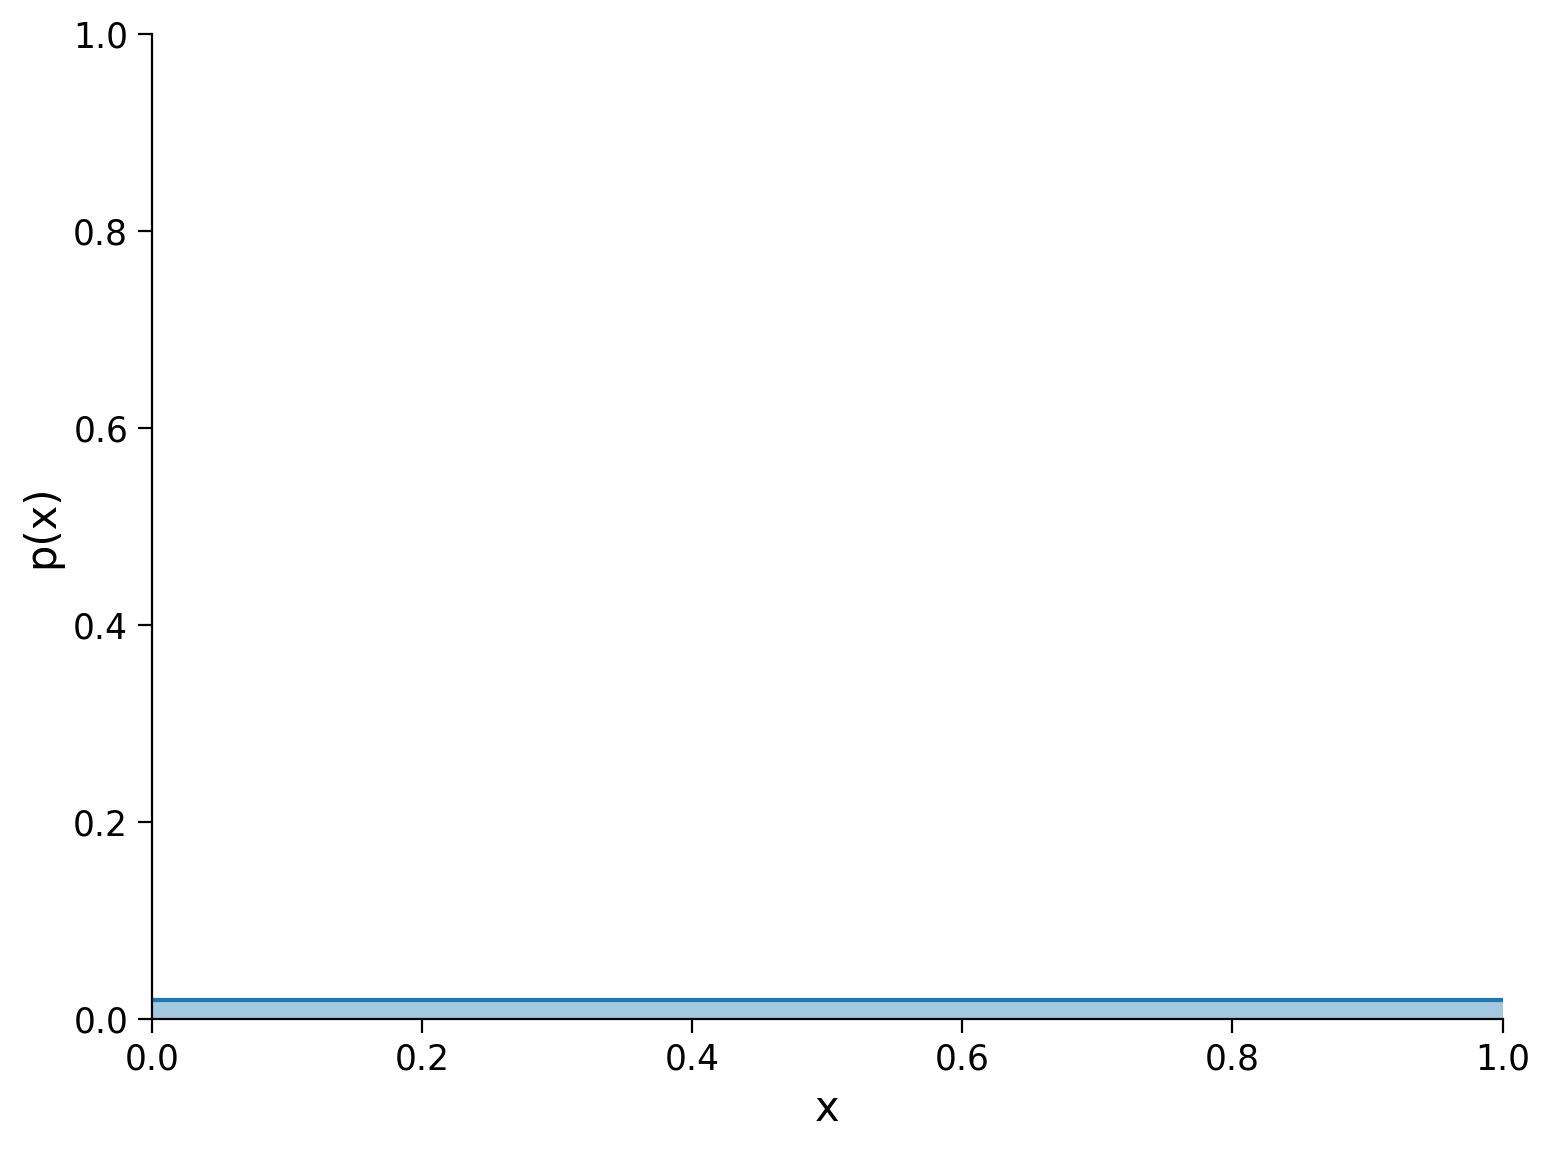

In [27]:

pmf = np.ones(n_bins) / n_bins  # [1/N] * N

pmf_ = np.insert(pmf, 0, pmf[0])
plt.plot(bins, pmf_, drawstyle="steps")
plt.fill_between(bins, pmf_, step="pre", alpha=0.4)
plt.xlabel("x")
plt.ylabel("p(x)")
plt.xlim(x_range)
plt.ylim(0, 1)
plt.show()


What is the entropy of the probability distribution shown above?

In [ ]:

# Call entropy function and print result
print(f"{entropy(pmf):.2f} bits")


5.64 bits


The uniform distribution has higher entropy than the previous two distributions, because we have higher ignorance of the system (less certain about the outcome) in this case.

Consider the 3 kinds of probability distributions that we considered in the What models section:

**Deterministic**

**Uniform**

**Exponential**

Now we can calculate the entropy of these 3 distributions:

In [28]:

n_bins = 50
mean_isi = 0.025
isi_range = (0, 0.25)

bins = np.linspace(*isi_range, n_bins + 1)
mean_idx = np.searchsorted(bins, mean_isi)

# 1. all mass concentrated on the ISI mean
pmf_single = np.zeros(n_bins)
pmf_single[mean_idx] = 1.0

# 2. mass uniformly distributed about the ISI mean
pmf_uniform = np.zeros(n_bins)
pmf_uniform[0:2*mean_idx] = 1 / (2 * mean_idx)

# 3. mass exponentially distributed about the ISI mean
pmf_exp = stats.expon.pdf(bins[1:], scale=mean_isi)
pmf_exp /= np.sum(pmf_exp)


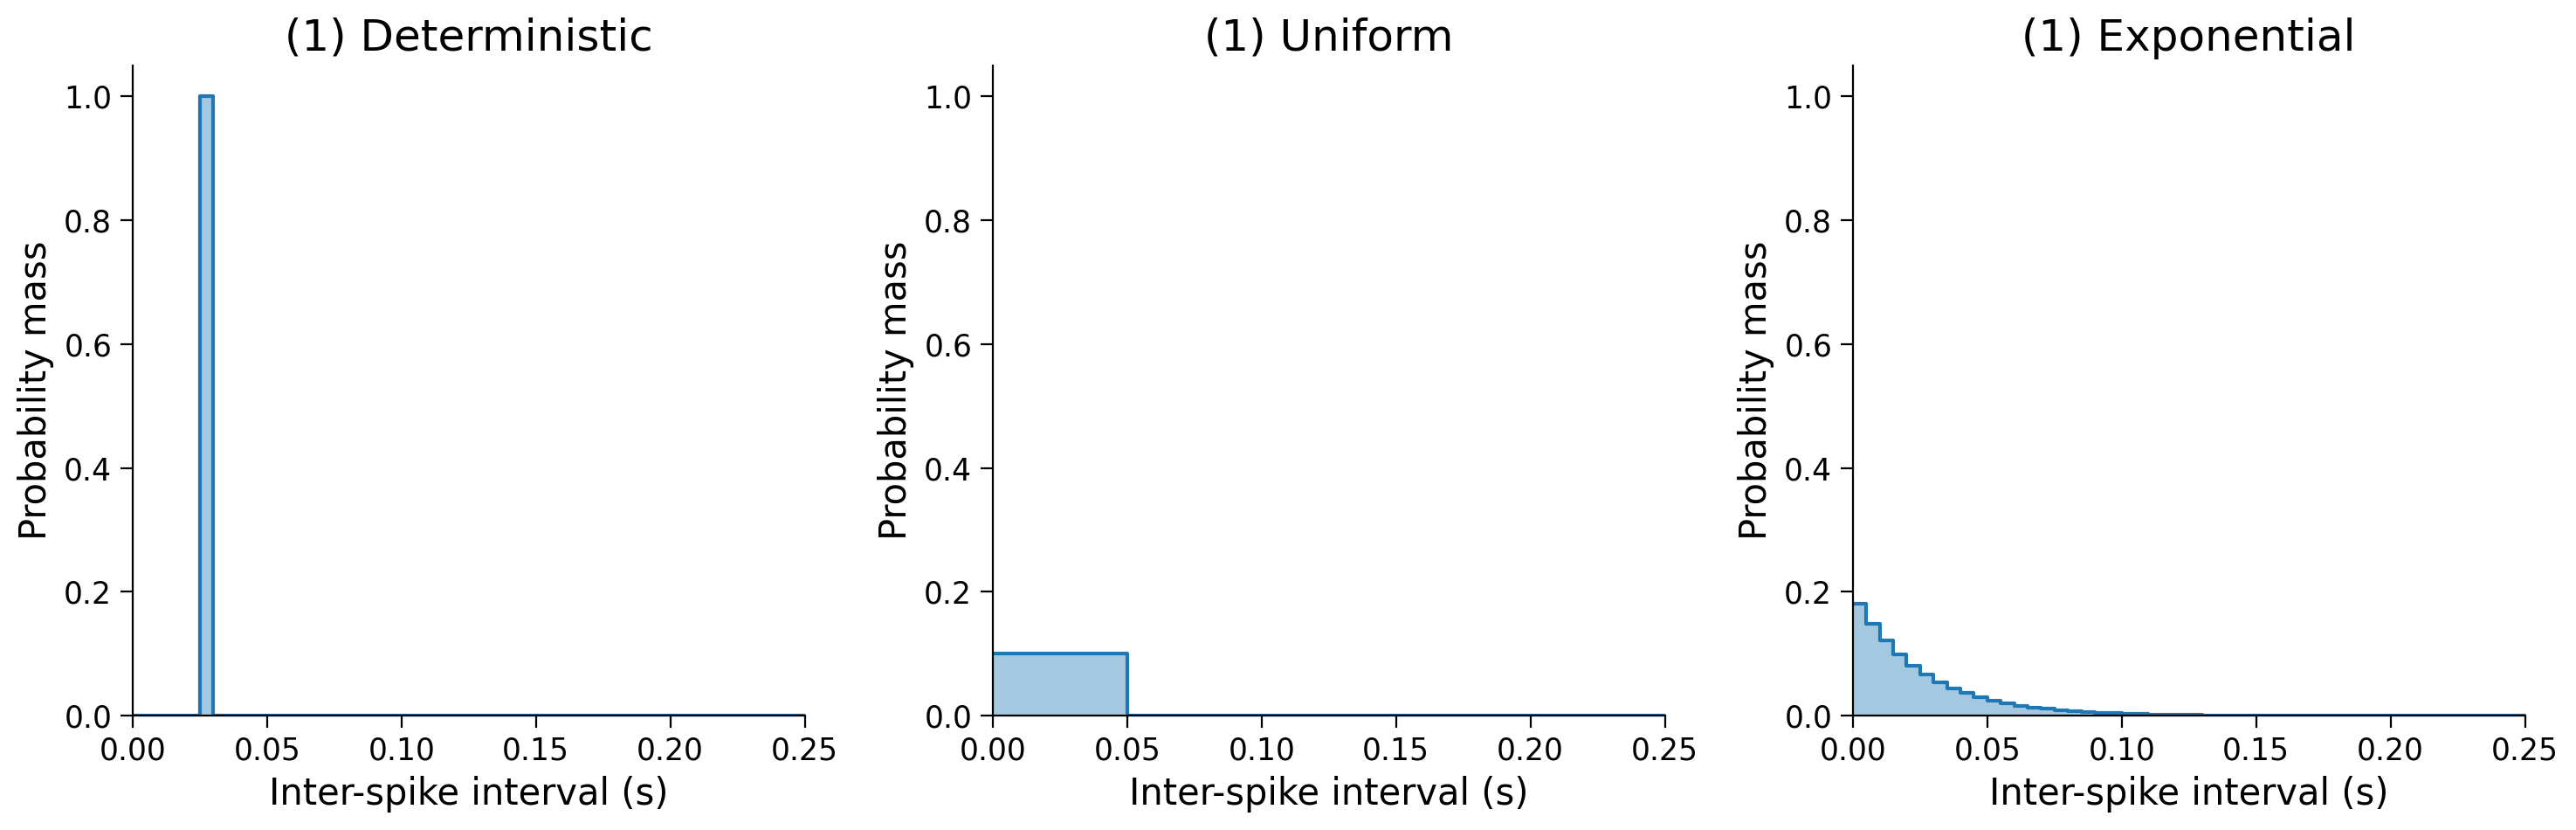

In [29]:

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

dists =  [# (subplot title, pmf, ylim)
          ("(1) Deterministic", pmf_single, (0, 1.05)),
          ("(1) Uniform", pmf_uniform, (0, 1.05)),
          ("(1) Exponential", pmf_exp, (0, 1.05))]

for ax, (label, pmf_, ylim) in zip(axes, dists):
  pmf_ = np.insert(pmf_, 0, pmf_[0])
  ax.plot(bins, pmf_, drawstyle="steps")
  ax.fill_between(bins, pmf_, step="pre", alpha=0.4)
  ax.set_title(label)
  ax.set_xlabel("Inter-spike interval (s)")
  ax.set_ylabel("Probability mass")
  ax.set_xlim(isi_range)
  ax.set_ylim(ylim)
plt.show()



In [30]:

print(
  f"Deterministic: {entropy(pmf_single):.2f} bits",
  f"Uniform: {entropy(pmf_uniform):.2f} bits",
  f"Exponential: {entropy(pmf_exp):.2f} bits",
  sep="\n",
)

Deterministic: 0.00 bits
Uniform: 3.32 bits
Exponential: 3.77 bits


The results show that the exponential distribution has the highest entropy.  

### Compute the entropy of the ISIs data

First, we need to use the following equation to convert the ISIs distribution into a probability distribution:

$$ p_i = \frac{n_i}{\sum\nolimits_{i}n_i} $$

where $p_i$ is the probability of an ISI falling within a particular interval $i$,

and $n_i$ is the count of how many ISIs were observed in that interval.

Make sure we have downloaded the data:

In [31]:

import io
import requests
r = requests.get('https://osf.io/sy5xt/download')
if r.status_code != 200:
  print('Could not download data')
else:
  steinmetz_spikes = np.load(io.BytesIO(r.content), allow_pickle=True)['spike_times']



Visualize the data collected from a neuron:

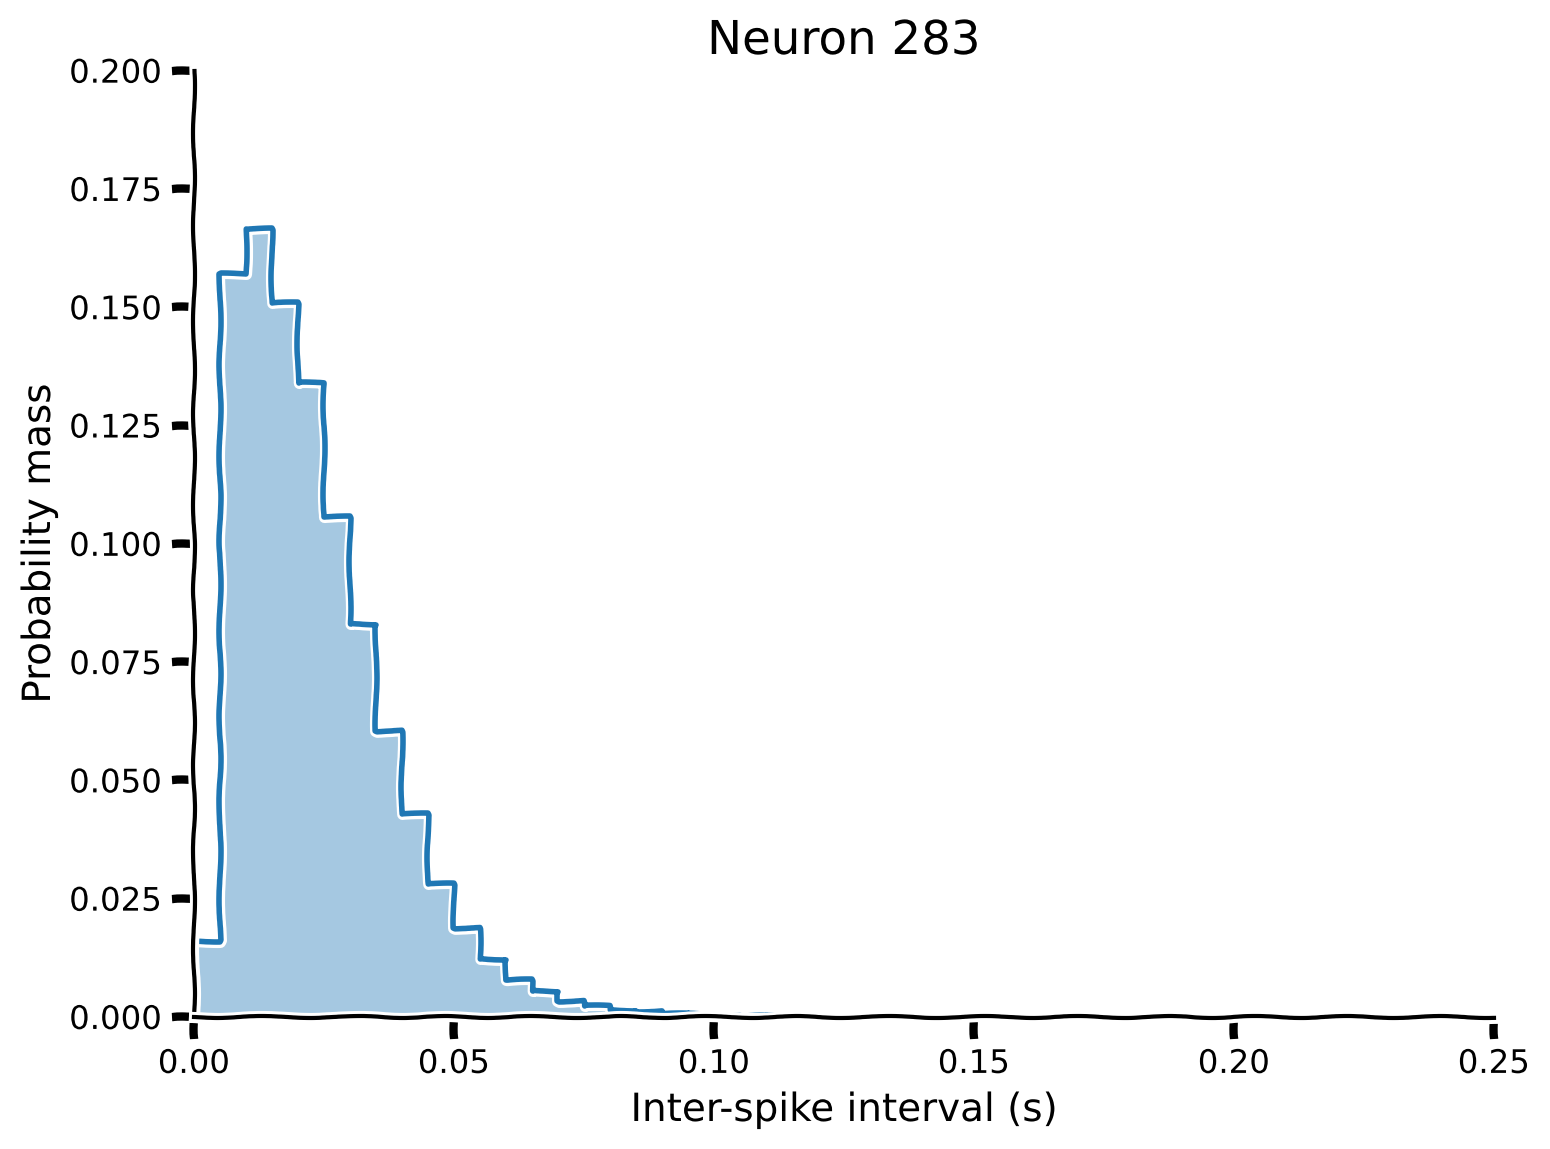

In [32]:

def pmf_from_counts(counts):
  """Given counts, normalize by the total to estimate probabilities."""
  pmf = counts / np.sum(counts)
  return pmf


# Get neuron index
neuron_idx = 283

# Get counts of ISIs from Steinmetz data
isi = np.diff(steinmetz_spikes[neuron_idx])
bins = np.linspace(*isi_range, n_bins + 1)
counts, _ = np.histogram(isi, bins)

# Compute pmf
pmf = pmf_from_counts(counts)

# Visualize
with plt.xkcd():
  plot_pmf(pmf, isi_range)


Then we can use the function we wrote to calculate the entropy of ISIs from this neuron:

In [33]:

print(f"Entropy for Neuron {neuron_idx}: {entropy(pmf):.2f} bits")

Entropy for Neuron 283: 3.36 bits


We can use the following interactive demo to calculate the entropy of ISIs from different neurons:

In [34]:

def _pmf_from_counts(counts):
  """Given counts, normalize by the total to estimate probabilities."""
  pmf = counts / np.sum(counts)
  return pmf


def _entropy(pmf):
  """Given a discrete distribution, return the Shannon entropy in bits."""
  # remove non-zero entries to avoid an error from log2(0)
  pmf = pmf[pmf > 0]
  h = -np.sum(pmf * np.log2(pmf))
  # absolute value applied to avoid getting a -0 result
  return np.abs(h)


@widgets.interact(neuron=widgets.IntSlider(0, min=0, max=(len(steinmetz_spikes)-1)))
def steinmetz_pmf(neuron):
  """ Given a neuron from the Steinmetz data, compute its PMF and entropy """
  isi = np.diff(steinmetz_spikes[neuron])
  bins = np.linspace(*isi_range, n_bins + 1)
  counts, _ = np.histogram(isi, bins)
  pmf = _pmf_from_counts(counts)

  plot_pmf(pmf, isi_range)
  plt.title(f"Neuron {neuron}: H = {_entropy(pmf):.2f} bits")
  plt.show()

interactive(children=(IntSlider(value=0, description='neuron', max=733), Output()), _dom_classes=('widget-inte…

### What does the distribution of ISIs suggest about the neural system?

# Question #3

1. What does the exponential distribution of ISIs suggest about the constraint in the neural system?

2. The ISIs of some neurons seem to be following an exponential distribution, but the ISIs of some other neurons seem to be following other distributions and have different entropy. What does it suggest about the neural system?

3. What might be the differences between a neuron with high ISIs entropy and a neuron with low ISIs entropy?



Please anser below:
1. Neural system or the cluster of neurons with exponential ISIs distribution have less entropy, hence more predictable/deterministic, less ignorance of the neural system, and faster firing of neurons, which means that same neuron is active all the time for a specific task
2. Not all parts of the brain or the neural system or the neurons is/are completely active/responsible during/for any task
3. Neurons with high ISIs entropy (non exponential like fit) are less involved or responsible than neurons with less ISIs entropy for a given task

### The maximum entropy principle

The Maximum Entropy Principle in statistics is a fundamental concept used to derive probability distributions based on limited information while making the fewest assumptions about the unknown data.

It states that, among all possible probability distributions that satisfy the given constraints, the type of the random variable (discrete or continuous), and the support (e.g., positive or nonnegative), the distribution with the maximum entropy should be chosen because it is the least biased representation of the available information.


What is the probability distribution if we maximum entropy and the only non-trivial constraint is that the mean of the random variable is fixed?

The type of random variable X (ISI) and the support:

$$ X\;is\;continuous\;and\;X \geq 0 $$

Constraints:

$$ \int_{-\infty}^\infty p(x) \, dx = 1 $$

$$ E(X) = \int_{-\infty}^\infty x p(x) \, dx = \mu $$

Where the first constraint is because probabilities must sum to 1,

the second constraint requires the mean of random variable $X$ to be a fixed value $\mu$.



Then we can use the method of Lagrange multipliers to maximize entropy under the above constraints. (If you are not familiar with this part, you can find a Calculus textbook for reference)



Set Up the Lagrangian:

$$ L = entropy + \lambda_1 constraint_1 + \lambda_2 constraint_2 $$

$$ L = -\int_{0}^\infty p(x) \log p(x) \, dx
+ \lambda_1 \left( \int_{0}^\infty p(x) \, dx - 1 \right)
+ \lambda_2 \left( \int_{0}^\infty x p(x) \, dx - \mu \right) $$

The integrations start from 0 because we know the ISIs must be non-negative.



Then we can calculate the functional derivative of $L$ with respect to $p(x)$ and set the derivative to 0 to maximize entropy:



$$ \frac{\delta L}{\delta p(x)} = -\log p(x) - 1 + \lambda_1 + \lambda_2 x = 0 $$

$$ p(x) = e^{-1 + \lambda_1 + \lambda_2 x} = e^{-1+\lambda_1}e^{\lambda_2 x} = Ae^{\lambda_2 x} $$  

Where $A$ is the constant $e^{-1+\lambda_1}$.



The next step is solve for the Lagrange multipliers $\lambda_1$ and $\lambda_2$ using the constraints:

$$ \int_{0}^\infty p(x) \, dx = 1 \quad \Rightarrow \quad \int_{0}^\infty A e^{\lambda_2 x} \, dx = 1 \quad \Rightarrow \quad -\frac{A}{\lambda_2} = 1 \quad \Rightarrow \quad \lambda_2 = -A < 0 $$


$$ \int_{0}^\infty x p(x) \, dx = \mu \quad \Rightarrow \quad \int_{0}^\infty A x e^{\lambda_2 x} \, dx = \mu \quad \Rightarrow \quad \int_{0}^\infty - \lambda_2 x e^{\lambda_2 x} \, dx = \mu $$

The integral $\int_{0}^\infty - \lambda_2 x e^{\lambda_2 x} \, dx$ can be calculated using integration by parts: (please refer to a Calculus textbook if you are not familiar with it)

$$\int_{0}^\infty - \lambda_2 x e^{\lambda_2 x} \, dx = \frac{1}{\lambda_2} \int_{0}^\infty - \lambda_2 x e^{\lambda_2 x} \, d(\lambda_2 x) = \frac{1}{\lambda_2} \int_{-\infty}^0 y e^{y} \, dy = \frac{1}{\lambda_2} \int_{-\infty}^0 y \, d(e^{y}) = \frac{1}{\lambda_2} \left( ye^{y}\big|_{-\infty}^{0} - \left(\int_{-\infty}^0 e^{y} \, dy \right) \right) = -\frac{1}{\lambda_2} $$

Where $y = \lambda_2 x$



Therefore,

$$ -\frac{1}{\lambda_2} = \mu \quad \Rightarrow \quad \lambda_2 = - \frac{1}{\mu}, A = -\lambda_2 = \frac{1}{\mu}$$


$$ p(x) = Ae^{\lambda_2 x} = \frac{1}{\mu} e^{-\frac{x}{\mu}}, (x \geq 0) $$

In summary, ISIs must be following an exponential distribution if we derive the probability distribution following the maximum entropy principle and the only constraint is that the mean is a fixed value.



### Table of probability distributions and corresponding maximum entropy constraints

| **Distribution name** | **Probability density / mass function**                               | **Maximum Entropy constraint**                  | **Support**                     |
|------------------------|----------------------------------------------------------------------|-----------------------------------------------|---------------------------------|
| Uniform (discrete)     | $f(k) = \frac{1}{b - a + 1}$                                         | None                                           | $\{a, a+1, \dots, b-1, b\}$     |
| Uniform (continuous)   | $f(x) = \frac{1}{b - a}$                                             | None                                           | $[a, b]$                        |
| Bernoulli              | $f(k) = p^k (1-p)^{1-k}$                                             | $\mathbb{E}[K] = p$                            | $\{0, 1\}$    |
| Geometric              | $f(k) = (1-p)^{k-1} p$                                               | $\mathbb{E}[K] = \frac{1}{p}$                  | $\mathbb{N} \setminus \{0\}$    |                   
| Binomial               | $f(k) = \binom{n}{k} p^k (1-p)^{n-k}$                                | $\mathbb{E}[X] = n p$                          | $\{0, \dots, n\}$               |
| Poisson                | $f(k) = \frac{\lambda^k e^{-\lambda}}{k!}$                           | $\mathbb{E}[X] = \lambda$                      | $\mathbb{N} = \{0, 1, \dots\}$  |
| Exponential            | $f(x) = \lambda \exp(-\lambda x)$                                    | $\mathbb{E}[X] = \frac{1}{\lambda}$            | $[0, \infty)$                   |
| Normal                 | $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$ | $\mathbb{E}[X] = \mu, \mathbb{Var}[X] = \sigma^2$ | $(-\infty, \infty)$             |




### The relationship between different probability distributions shown above


### 1. **Bernoulli Distribution**
- **Definition**: Models a single trial with two possible outcomes: success (1) or failure (0).
  $$ P(X = 1) = p, \quad P(X = 0) = 1 - p, \quad X \sim \text{Bernoulli}(p). $$
- **Key Properties**:
  - Mean: $$ \mathbb{E}[X] = p $$
  - Variance: $$ \mathrm{Var}[X] = p(1 - p) $$
- **Relationships**:
  - **Building Block for Geometric**: A Geometric distribution is the number of Bernoulli trials until the first success.
  - **Building Block for Binomial**: A Binomial distribution is the sum of \(n\) independent Bernoulli trials.



---

### 2. **Geometric Distribution**
- **Definition**: Models the number of Bernoulli trials until the first success.
  $$ P(X = k) = (1 - p)^{k - 1} p, \quad k = 1, 2, 3, \dots, \quad X \sim \text{Geometric}(p). $$
- **Key Properties**:
  - Mean: $ \mathbb{E}[X] = \frac{1}{p} $
  - Variance: $ \mathrm{Var}[X] = \frac{1 - p}{p^2} $
- **Relationships**:
  - **Derived from Bernoulli**: The Geometric distribution is the number of Bernoulli trials needed to achieve the first success.
  - **Memoryless Property**: The Geometric distribution is memoryless:
    $$ P(X > k + m \mid X > k) = P(X > m). $$


---

### 3. **Binomial Distribution**
- **Definition**: Models the number of successes in \(n\) independent Bernoulli trials with success probability \(p\).
  $$ P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}, \quad X \sim \text{Binomial}(n, p). $$
- **Key Properties**:
  - Mean: $$ \mathbb{E}[X] = n p $$
  - Variance: $$ \mathrm{Var}[X] = n p (1 - p) $$
- **Relationships**:
  - **Sum of Bernoulli Trials**: A Binomial random variable is the sum of \(n\) independent Bernoulli random variables.
  - **Limit to Poisson**: For rare events $(p \to 0$ and $n \to \infty$ such that $n p = \lambda$):

    $$ \text{Binomial}(n, p) \to \text{Poisson}(\lambda). $$

---

### 4. **Poisson Distribution**
- **Definition**: Models the number of events in a fixed interval of time or space, assuming events occur independently and at a constant average rate $\lambda$.
  $$ P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad X \sim \text{Poisson}(\lambda). $$
- **Key Properties**:
  - Mean: $$ \mathbb{E}[X] = \lambda $$
  - Variance: $$ \mathrm{Var}[X] = \lambda $$
  - Sum of independent Poisson variables is still Poisson:
  
  if $X \sim \text{Poisson}(\lambda_1)$ and $Y \sim \text{Poisson}(\lambda_2)$, then $X + Y \sim \text{Poisson}(\lambda_1 + \lambda_2)$
- **Relationships**:
  - **Limit of Binomial**: The Poisson distribution is the limiting case of the Binomial distribution when $n \to \infty$ and $p \to 0$ (rare events).
  - **Counts in Poisson Process**: In a Poisson process, the Poisson distribution describes the number of events in a fixed interval.
  - **Exponential Connection**: The time between events in a Poisson process follows an Exponential distribution.

---

### 5. **Exponential Distribution**
- **Definition**: Models the time interval between successive events in a Poisson process.
  $$ f(t) = \lambda e^{-\lambda t}, \quad t \geq 0, \quad T \sim \text{Exponential}(\lambda). $$
- **Key Properties**:
  - Mean: $$ \mathbb{E}[T] = \frac{1}{\lambda} $$
  - Variance: $$ \mathrm{Var}[T] = \frac{1}{\lambda^2} $$
- **Relationships**:
  - **Interarrival Times in Poisson Process**: The time between successive events in a Poisson process is Exponential.
  - **Memoryless Property**: The Exponential distribution is memoryless:
    $$ P(T > t + s \mid T > t) = P(T > s). $$

---

### 6. **Gaussian (Normal) Distribution**
- **Definition**: Models continuous data that clusters symmetrically around a mean value. The Gaussian distribution is defined as:
  $$ f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right), \quad X \sim N(\mu, \sigma^2). $$
  Where:
  - $\mu$: Mean (center of the distribution),
  - $\sigma^2$: Variance (spread of the distribution).
- **Key Properties**:
  - Mean: $ \mathbb{E}[X] = \mu $
  - Variance: $ \mathrm{Var}[X] = \sigma^2 $
  - Symmetry: The Gaussian is symmetric around the mean $\mu$.
  - Infinite Support: Defined over $x \in (-\infty, \infty)$.
- **Relationships**:
  - **Central Limit Theorem**: The Gaussian distribution arises as the limiting distribution for the sum of a large number of independent, identically distributed random variables.
  - **Approximation for Binomial and Poisson**:
    - For large $n$, the Binomial distribution can be approximated by:
      $$ \text{Binomial}(n, p) \approx N(np, np(1-p)). $$
    - For large $\lambda$, the Poisson distribution can be approximated by:
      $$ \text{Poisson}(\lambda) \approx N(\lambda, \lambda). $$

### Summary of Relationships:

| **Distribution**      | **Key Relationship**                                                                                  |
|------------------------|------------------------------------------------------------------------------------------------------|
| **Bernoulli**          | Building block for Binomial and Geometric distributions.                                             |
| **Binomial**           | Sum of independent Bernoulli trials; approximates Poisson for rare events.                           |
| **Geometric**          | Number of Bernoulli trials until the first success; memoryless property.                             |
| **Poisson**            | Limit of Binomial for rare events; describes counts in a Poisson process.                            |
| **Exponential**        | Time between events in a Poisson process; related to Poisson through interarrival times.             |
| **Gaussian**           | Limit of sum of many independent random variables (Central Limit Theorem); approximates Binomial and Poisson for large parameters. |







### The Poisson model of neurons

The Poisson model of neurons is a widely used mathematical framework in neuroscience to describe the spiking activity of neurons. It assumes that the timing of spikes (action potentials) follows a Poisson process, characterized by its simplicity and ability to model the stochastic nature of neuronal firing.

**The Poisson Process**:

A Poisson process is a statistical process used to model events that occur randomly over time, with a constant average rate.

In the context of neurons, the "events" are spikes, and the rate parameter λ(t) (spikes per second) represents the neuron's firing rate.

Properties:

1. Independence: The timing of one spike is independent of the timing of other spikes.

2. Constant or Time-Varying Rate:
A homogeneous Poisson process has a constant firing rate λ.
A non-homogeneous Poisson process allows λ(t) to vary over time, depending on the stimulus or other factors.

**When using Poisson process to model neural firing, we are assuming that the spike times of neurons are completely random and only the firing rate carries information about a signal.**

\

We usually use **Fano factor** to measure whether a stochastic process is Poisson-like or not:

$$ \text{Fano Factor} = \frac{Var[r]}{E[r]} $$

Where $r$ is the spike count.

**The Fano factor for a Poisson process is exactly 1.**

**Fano factor is greater than 1:**

It indicates that the spiking activity is overdispersed (more variable than a Poisson process). This can happen due to external variability or other sources of noise.

**Fano factor is less than 1:**

It indicates that the spiking activity is underdispersed (less variable than a Poisson process). This can happen when the spiking activity is highly regular, such as in some forms of deterministic neural firing.



## Neural Information Encoding and Mutual Information

**Mutual Information (MI)** is a concept from information theory that quantifies the amount of information shared between two random variables. It measures how much knowing one variable reduces uncertainty about the other.

**Mutual Information** Measures **Neural Encoding Efficiency**:

$I(S;R)$ quantifies how much information about $S$ (stimuli) is contained in $R$ (neural responses):

Higher $I(S;R)$ indicates better encoding of the stimulus by the neural activity.

---

## **Definition**

Mutual information between two random variables $ X $ and $ Y $ is defined as:
$$
I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}
$$

Alternatively, in terms of **entropy**:

$$
I(X; Y) = H(X) + H(Y) - H(X, Y) = H(X) - H(X|Y) = H(Y) - H(Y|X)
$$

Where:
- $ p(x, y) $: Joint probability distribution of $ X $ and $ Y $.
- $ p(x) $: Marginal probability distribution of $ X $.
- $ p(y) $: Marginal probability distribution of $ Y $.
- $ H(X) $: Entropy of random variable $X$.
- $ H(Y) $: Entropy of random variable $Y$.
- $ H(X,Y) $: Joint entropy of random variables $X$ and $Y$.

$$ H(X, Y) = - \sum_{x \in X} \sum_{y \in Y} p(x, y) \log p(x, y) $$

Property: $H(X,Y)= H(X) + H(Y|X)$

- $ H(Y|X) $: Conditional entropy of random variable $Y$ given $X$.

$$ H(Y \mid X) = - \sum_{x \in X} p(x) \sum_{y \in Y} p(y \mid x) \log p(y \mid x) $$

---

## **Intuition**

1. **Reduces Uncertainty**: MI tells us how much knowing $ X $ reduces uncertainty about $ Y $, and vice versa.
2. **Independence**:
   - If $ X $ and $ Y $ are **independent**, their joint distribution $ p(x, y) = p(x)p(y) $, so $ I(X; Y) = 0 $.
   - If $ X $ and $ Y $ are **completely dependent**, $ I(X; Y) $ equals the entropy of $ X $ (or $ Y $).
3. **Symmetry**:
   - $ I(X; Y) = I(Y; X) $: Mutual information is symmetric.

---

## **Properties**

1. **Non-Negativity**:
   $
   I(X; Y) \geq 0
   $
2. **Symmetry**:
   $
   I(X; Y) = I(Y; X)
   $
3. **Relationship with Entropy**:
   $
   I(X; Y) \leq \min(H(X), H(Y))
   $
4. **Additivity**:
   For independent pairs of variables:
   $
   I(X, Z; Y) = I(X; Y) + I(Z; Y)
   $

---

## **Applications**

1. **Machine Learning**:
   - **Feature Selection**: Identify features with the highest mutual information with the target variable.
   - **Clustering**: MI can measure the similarity between clusters and ground truth labels.

2. **Communications**:
   - Quantify the amount of information transmitted over a noisy channel (Shannon's channel capacity theorem).

3. **Neuroscience**:
   - Measure the dependency between neural activity and stimuli or behaviors.

---

## **Visualization**

Mutual information can be visualized as the overlapping area in a Venn diagram of $ H(X) $ and $ H(Y) $, where the overlap represents $ I(X; Y) $, the shared information between $ X $ and $ Y $.

---

In summary, **mutual information** is a measure of dependency between variables, capturing both linear and non-linear relationships, and is widely applicable across disciplines.





**Example**

Suppose we have two variables:
- $ X $: Weather (Sunny, Rainy).
- $ Y $: Carrying an Umbrella (Yes, No).

The joint probability distribution might look like:

| Weather  | Umbrella | Probability \( p(x, y) \) |
|----------|----------|---------------------------|
| Sunny    | Yes      | 0.1                       |
| Sunny    | No       | 0.4                       |
| Rainy    | Yes      | 0.4                       |
| Rainy    | No       | 0.1                       |

From this, we can calculate the marginal distributions $ p(x) $, $ p(y) $, and the joint entropy $ H(X, Y) $. Using these, the mutual information $ I(X; Y) $ can be computed to quantify how much knowing the weather tells us about carrying an umbrella, or vice versa.

---

# Question #4



1. Based on the theories introduced above and the ISIs data distribution we have examined, what do you think about the properties of neural firing in this dataset? For example, do you think the Poisson model is a good approximation of these neurons? Why?

2. According to the entropy computations, do ISIs of different neurons have the same entropy? What might be the reasons that the ISIs of some neurons have higher entropy and the ISIs of some other neurons have lower entropy?

3. Suppose the ISIs of neuron $A$ has higher entropy than the ISIs of neuron $B$ and both of them are encoding some kinds of information (external stimuli), the information encoded by which neuron do you think is more reliable? Why?

4. Suppose the ISIs of neuron $A$ has higher entropy than the ISIs of neuron $B$, which neuron do you think has higher capacity to encode more information? Why?

Hint: To answer question 3 and 4, you may find the concept of mutual information helpful.

Please anwer below:
1. Yes, under specific conditions, the Poisson model is a good approximation. According to the maximum entropy principle, if the only known constraint is the average firing rate, the distribution that maximizes entropy is exponential
2. Entropy tells us how constrained the neural code is. Different entropy values across neurons imply different functional roles or different underlying mechanisms
3. Neuron B (the one with lower ISI entropy) encodes information more reliably. Lower entropy -> stronger constraints -> higher reliability
4. Neuron A (the one with higher ISI entropy) has higher capacity to encode more information. Higher entropy -> more possible messages -> higher capacity

# Computational Level, Algorithmic (or Representational) Level, Implementational (or Hardware) Level models

The Computational Level, Algorithmic (or Representational) Level, and Implementational (or Hardware) Level are the three levels of analysis proposed by David Marr in his influential framework for understanding information processing systems.

## Computational Level models

This level addresses what the system does and why. It focuses on the goals of the computation and the logic behind them.

**Key Questions:**

What problem is the system solving?

What is the input and what is the desired output?

Why is this computation being performed (e.g., survival, efficiency)?

**Example:**

Bayesian theory of cognition  


### The Bayesian approach

The Bayesian approach is a statistical method based on Bayes' theorem, which describes how to update the probability of a hypothesis as more evidence or information becomes available. It is widely used in various fields, including statistics, machine learning, cognitive science, neuroscience, and artificial intelligence.

**The Bayes' Theorem**

At its core, Bayes' theorem is a simple mathematical formula:

$$ P(H|E) = \frac{P(E|H) P(H)}{P(E)} \propto P(E|H) P(H) $$

Where:
- \\( P(H|E) \\): The **posterior probability** – the probability of the hypothesis \\( H \\) being true after observing the evidence \\( E \\).  
- \\( P(E|H) \\): The **likelihood** – the probability of observing the evidence \\( E \\), assuming the hypothesis \\( H \\) is true.  
- \\( P(H) \\): The **prior probability** – the probability of the hypothesis \\( H \\) before observing the evidence.  
- \\( P(E) \\): The marginal probability of the evidence \\( E \\) (**marginal likelihood**) – the probability of observing \\( E \\) under all possible hypotheses.


The **philosophy** behind Bayesian approach:

1. There is uncertainty that we need to represent.

2. When we ask a question, we want to know how likely the answer is, as well as how confident we are in the answer.

3. You should use all available information to make a decision.

4. The Bayesian approach is used to define the **optimal way** for making a decision (maximum posterior) under uncertainty given the all of the available information (prior and likelihood).

## Algorithmic (or Representational) Level models

This level explains how the computation is carried out. It focuses on the specific representations and algorithms the system uses to achieve its goal.

**Key Questions:**

What representations are used to encode the input, intermediate states, and output?

What processes or algorithms transform the input into the output?

**Example:**

The poissible ways of doing Bayesian inference in biological neural networks

## Implementational (or Hardware) Level models

This level examines how the algorithm is physically realized. It focuses on the physical or biological substrate that executes the computations.

**Key Questions:**

What is the physical medium (e.g. ion channels, neural transmitters) used to perform the computation?

How are the representations and algorithms implemented in this medium?

**Example**:

The integrate and fire models that we discussed above in the How models section may be considered as a simple model at the Implementational (or Hardware) Level models.

**The models at this level are usually (maybe) less important for understanding human cognition than models at the other two levels.**

# Theory-driven models and Data-driven models

## Theory-driven models

These models are developed based on pre-existing theories or hypotheses about cognitive processes and brain functions. They aim to formalize theoretical concepts into computational frameworks.

**Characteristics**:

**Foundation on First Principles**: Build a conceptual model or theoretical framework based on a few first principles.

**Simplified Representations**: Often abstract and simplified to focus on key mechanisms or principles of a theory.

<br>

**Examples**:

**Neural network models**: Inspired by biological neural networks, built to simulate learning and memory processes (e.g., the Hopfield network, convolutional neural network).

**Reinforcement learning models**: Inspired by theories in many different fields: optimal control, operations research, psychology, neuroscience, etc.

<br>

**Pros**:

Provide insights into underlying principles of cognition and brain function.
Guide experimental design by making predictions.

Allow for explicit testing of theoretical assumptions.

**Cons**:

May oversimplify real-world data or ignore complexities.

Depend heavily on the validity of the initial theory and first principles.

## Data-driven models

These models are created by leveraging empirical data, often without strong initial theoretical constraints, to uncover patterns, predict outcomes, or generate hypotheses.

**Characteristics**:

**Empirical Focus**: Built using large-scale data from experiments, brain imaging, or behavioral studies.

**Model Formation**: Uses statistical or machine learning techniques to discover relationships and structures within data.

<br>

**Examples**:

**Machine learning models**: Classify or predict cognitive states from brain imaging data (e.g., fMRI or EEG).

**Dimensionality reduction models**: Such as principal component analysis (PCA) or independent component analysis (ICA) to analyze brain activity patterns.

<br>

**Pros**:

Handle complex and high-dimensional datasets effectively.
Often reveal patterns not apparent in theory-driven models.
Can generate new hypotheses for theory development.

**Cons**:

Risk of overfitting or creating models that lack interpretability.
May not provide insights into causal mechanisms or principles.
Depend heavily on the quality and representativeness of the data.

## Complementary Roles of theory-driven and data-driven models  

**Theory-driven models focus on understanding "why" and "how". (Top Down)**

**Data-driven models excel at answering "what" and "how". (Bottom Up)**

**Interdependence**:

Data-driven insights can inspire new theories or refine existing ones.
Theory-driven models can guide the collection and interpretation of data.

**Hybrid Approaches**:

Increasingly common in cognitive neuroscience, combining theoretical insights with data-driven techniques. For example, fitting a biologically inspired neural network (theory-driven) to neuroimaging data (data-driven).


# Computational models and Mathematical models

## Mathematical models

Mathematical models use equations and formal mathematical expressions to describe cognitive or neural phenomena. These models focus on capturing key relationships and patterns in a concise and often abstract form.

**Characteristics**:

1. Represent systems using mathematical equations, such as differential equations, linear algebra, or probability distributions.
Analytical Solutions: Emphasis on deriving insights or predictions from the model's equations.

2. Often focus on the general principles or laws governing behavior rather than specific mechanisms.

<br>

**Strengths**:

Provide clear, concise insights into relationships between variables.

Easier to analyze mathematically for general principles.

Less computationally intensive compared to simulations.

**Limitations**:

May oversimplify complex processes.

Often require assumptions that may not fully align with biological reality.

Limited in modeling emergent behaviors or nonlinear systems.

<br>

**Examples**:

**Psychophysics theories that describe the relationship between physical stimulus properties and sensory perception**: Weber's Law, Fechner's Law, Stevens' Power Law.

**Signal Detection Theory**: Signal Detection Theory (SDT) is a framework in psychology used to understand and model decision-making under conditions of uncertainty. It examines how individuals detect signals (e.g., stimuli or information) amidst noise (irrelevant or distracting background information).

**Social Choice Theory**: Explores how individual preferences aggregate into collective decisions. Includes famous results like Arrow's Impossibility Theorem, which states that no voting system can perfectly aggregate preferences without violating certain fairness criteria.


## Computational models

**Computational models** are simulations or algorithms that mimic cognitive or neural processes using computational systems. They can also be algorithms that can help people solve complex computation problems that cannot be solved by hand. These models often aim to reproduce the behavior of cognitive systems and neural circuits, with a focus on the dynamic, process-oriented aspects of these systems.

**Characteristics**:

1. Using computer programs to compute the results or simulate neural computations.

2. Often focus on solving complex computation problems that cannot be solved by hand and model the specific mechanisms in the neural system.

<br>

**Strengths**:

Provide simulations of complex systems.

Can handle nonlinear interactions and feedback mechanisms.

**Limitations**:

Require significant computational resources.

Can become overly complex, making interpretation difficult (black box).

Risk of overfitting to specific data without generalizable insights.

<br>

**Examples**:

**Artificial Neural Networks (ANNs)**:

Hopfield network, convolutional neural network, recurrent neural network etc.

**Bayesian models with Markov chain Monte Carlo (MCMC) sampling**:

MCMC sampling is often used when there is no easy way to calculate the closed-form solution of the normalization constant in the posterior.  

**Reinforcement Learning Models**:

In order to get the optimal policy and value function, the Bellman Optimality Equation in reinforcement learning usually cannot be solved without using computer programs.

## The Principle of Computational Irreducibility

The **Principle of Computational Irreducibility**, introduced by computer scientist Stephen Wolfram in his book A New Kind of Science, states that certain systems or processes are inherently complex and cannot be simplified or accelerated through computational shortcuts. To understand or predict their behavior, these systems must be simulated step by step in full detail.

**Irreducibility of Computation**:

For some systems, the only way to determine their future state is to perform the entire computation, without any way to "compress" the process.
If a system requires 100 steps to evolve, there is no shortcut that allows the computation to be completed in fewer steps.

**Complex Behavior from Simple Rules**:

Even systems governed by very simple rules can exhibit behavior that is extraordinarily complex and unpredictable.
This demonstrates that simplicity in underlying rules does not necessarily result in simplicity in outcomes.

**Unpredictability**:

Computational irreducibility implies that even if we know a system's initial conditions and rules, we cannot predict its long-term behavior without performing the full computation.


### **Examples**:

**Cellular Automata**:

Wolfram's Rule 30 is a famous example. Despite being defined by a simple set of local rules, the pattern it generates is highly complex and cannot be predicted without simulating the automaton.

**Weather Systems**:

While weather follows physical laws like fluid dynamics, long-term predictions are inherently difficult because the system's evolution involves irreducible computation.

**Chaotic Systems**:

Chaotic systems, such as the three-body problem in physics, are highly sensitive to initial conditions and require detailed simulation for accurate predictions.

<br>

### **Limits of Computation**:

The principle highlights that even with unlimited computational power, some problems cannot be solved faster than by directly simulating the process.

<br>

Many natural and artificial systems cannot be fully understood through simplified models or equations. Computational irreducibility underscores the need for detailed simulations in fields like physics, biology, and neuroscience.

It challenges the traditional scientific notion that all phenomena can be reduced to simple laws or equations, showing instead that complexity can emerge from simplicity.